In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import logomaker
import os
import scipy.stats
import matplotlib.gridspec as gridspec
import glob
import sys
import numpy as np


# Used colorpalette
black = '#000000'
lightblack = '#333333'
darkgray = '#666666'
mediumgray = '#999999'
lightgray = '#CCCCCC'

darkred = '#FF0000'
red = '#FF3333'
lightred = '#FF6666'
pink ='#FF9999'
salmon = '#FFCCCC'

In [2]:
print('########################################################################')
print('#### Make supp_database_1 of Gralak et al, ©Antoni Gralak_04.07.2025 ###')
print('########################################################################')
print('Setting env...')



def plot_messages(messages, ax):
    """
    Display messages in a textbox-like format on the given axis.
    """
    ax.axis('off')
    message_text = "\n".join(messages)
    ax.text(0, 1, message_text, fontsize=9, verticalalignment='top', family='monospace')

def get_stacked_ylim(*dfs):
    """
    Given one or more ddG matrices, return the y-axis limits 
    needed to display all letter stacks properly.
    """
    max_stacks = []
    min_stacks = []
    for df in dfs:
        df = df.fillna(0)  # in case there are NaNs
        max_stacks.append(df[df > 0].sum(axis=1).max())
        min_stacks.append(df[df < 0].sum(axis=1).min())
    return min(min_stacks), max(max_stacks)


########################################################################
#### Make supp_database_1 of Gralak et al, ©Antoni Gralak_04.07.2025 ###
########################################################################
Setting env...


In [3]:
sys.path.append('/data/gralak/meSMiLEseq_github/meSMiLEseq')
import utils

In [4]:
# How many scatter point shall be filled
N_points_filled = 20
# how many to use for lin reg
N_lin_reg = 125 

In [10]:
TFs = os.listdir('/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication')

In [11]:
TFs[0]

'ZBTB46_DBD'

In [12]:
filtered_TFs = [tf for tf in TFs if not tf.endswith('.csv')]

In [22]:
filtered_TFs = ['ZNF716_FL']

In [23]:
letter_slope = {}
for TF in filtered_TFs:
    data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
    
    joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
    sep_matrices_path = os.path.join(data_path, 'separated/matrices/')
    
    
    # Search and read all the data
    files_joint = os.listdir(joint_matrices_path)
    ratios = [f for f in files_joint if f.endswith('ratios.csv')]
    pvals = [f for f in files_joint if f.endswith('significant.csv')]
    dGGs = [f for f in files_joint if f.endswith('bindingmode_2.csv')] #change to bm 2 if necessary

    files_sep = os.listdir(sep_matrices_path)
    meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_2.csv')]#change to bm 2 if necessary
    unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_2.csv')]#change to bm 2 if necessary


    # Read the data

    ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
    if not pvals:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'
    else:
        try:
            pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
            significant_kmer_count = len(pval)
            alert = None
        except FileNotFoundError:
            pval = None
            significant_kmer_count = 0
            alert = 'No significant kmers!'

    dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

    dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
    dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

    #Prepare alert messages
    messages = []
    if alert:
        messages.append(alert)
    elif significant_kmer_count < 20:
         messages.append("Poor enrichment (<20 significant kmers)")


    if pval is not None:
        # define how many kmers shall be filled out
        most_significant_kmers = ratio[ratio['significant'] ==  True].nsmallest(N_points_filled, ['pval_methl', 'pval_nonmethl'])
        most_significant_kmers = most_significant_kmers.head(N_points_filled)
        kmer_filled = most_significant_kmers['index']
        ratio['fill_plot'] = ratio['index'].isin(kmer_filled)
        # Append kmer info to messages
        messages.append("Top significant kmers:")
        max_messages = 0
        for _, row in most_significant_kmers.iterrows():
            if max_messages <= 10:
                messages.append(f"{row['index']}, x: {row['eluted_methl']:.3f}, y: {row['eluted_nonmethl']:.3f}, "
                f"pval_x: {row['pval_methl']:.1e}, pval_y: {row['pval_nonmethl']:.1e}")
                max_messages += 1
            else:
                break
            
        

        kmer_lin_reg = ratio[ratio['significant'] ==  True].nsmallest(N_lin_reg, ['pval_methl', 'pval_nonmethl'])['index']
        ratio['use_for_linreg'] = ratio['index'].isin(kmer_lin_reg)

    else:
        ratio['significant'] = False
        ratio['use_for_linreg'] = False
        ratio['fill_plot'] = False

            

    lin_reg = {}
    coords = {}
    if pval is not None:
        for spec, dataframe in ratio.groupby(['use_for_linreg', 'CpG']):
            if spec[0]:
                if spec[1]:
                    key = 'with_CG'
                else:
                    key = 'no_CG'
                        
                dataframe_no_nan = dataframe.dropna(subset=['eluted_methl', 'eluted_nonmethl']) #drop nan otherwise no linreg possible
                if not dataframe_no_nan.empty:
                    x_l = dataframe_no_nan.eluted_methl
                    y_l = dataframe_no_nan.eluted_nonmethl

                    if len(x_l) < 4 or len(y_l) < 4 or x_l.nunique() == 1 or y_l.nunique() == 1:
                            continue
                    else:        
                        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x_l, y_l)
                        lin_reg[key] = [slope, intercept, r_value, p_value, std_err]
                        x_vals = np.linspace(x_l.min(), x_l.max(), 100)
                        y_vals = slope * x_vals + intercept
                        coords[key] = {'x': x_vals, 'y': y_vals}
    

In [24]:
ratio.nlargest(20, 'eluted_nonmethl')

,index,input_methl,eluted_methl,input_nonmethl,eluted_nonmethl,CpG,pval_methl,pval_nonmethl,significant,fill_plot,use_for_linreg
3300,TATTTC,1.0,1.727817,1.0,1.609825,False,2.330564e-172,5.499384e-189,True,True,True
885,ATCTTA,1.0,1.702526,1.0,1.609068,False,2.949165e-201,3.146901e-249,True,True,True
1976,CTTAGT,1.0,1.828236,1.0,1.521024,False,1.069023e-285,2.411019e-236,True,True,True
3159,TACTAA,1.0,1.591493,1.0,1.460417,False,1.444375e-148,2.420750e-157,True,True,True
119,AACTTA,1.0,1.559019,1.0,1.458111,False,1.664399e-147,3.632691e-171,True,True,True
1969,CTTACA,1.0,1.673055,1.0,1.447798,False,2.384274e-202,4.260740e-179,True,True,True
3857,TTAGTA,1.0,1.581739,1.0,1.370009,False,1.854615e-178,6.657047e-172,True,True,True
218,AATCTT,1.0,1.385925,1.0,1.345741,False,6.649286e-104,3.465857e-137,True,False,True
629,AGCTTA,1.0,1.530369,1.0,1.340013,False,9.125841e-159,4.567917e-147,True,True,True
2039,GAAATA,1.0,1.918429,1.0,1.339895,False,7.520653e-232,1.366420e-110,True,True,True


In [11]:
ratio[ratio['index'] == 'TGGTAT']

,index,input_methl,eluted_methl,input_nonmethl,eluted_nonmethl,CpG,pval_methl,pval_nonmethl,significant,fill_plot,use_for_linreg
3736,TGGTAT,1.0,14.021277,1.0,15.1375,False,NaN,NaN,False,False,False


In [6]:
letter_slope = {}
for TF in filtered_TFs:
    data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
    
    joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
    sep_matrices_path = os.path.join(data_path, 'separated/matrices/')
    
    
    # Search and read all the data
    files_joint = os.listdir(joint_matrices_path)
    ratios = [f for f in files_joint if f.endswith('ratios.csv')]
    pvals = [f for f in files_joint if f.endswith('significant.csv')]
    dGGs = [f for f in files_joint if f.endswith('bindingmode_2.csv')] #change to bm 2 if necessary

    files_sep = os.listdir(sep_matrices_path)
    meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_2.csv')]#change to bm 2 if necessary
    unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_2.csv')]#change to bm 2 if necessary


    # Read the data

    ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
    if not pvals:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'
    else:
        try:
            pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
            significant_kmer_count = len(pval)
            alert = None
        except FileNotFoundError:
            pval = None
            significant_kmer_count = 0
            alert = 'No significant kmers!'

    dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

    dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
    dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

    #Prepare alert messages
    messages = []
    if alert:
        messages.append(alert)
    elif significant_kmer_count < 20:
         messages.append("Poor enrichment (<20 significant kmers)")


    if pval is not None:
        # define how many kmers shall be filled out
        most_significant_kmers = ratio[ratio['significant'] ==  True].nsmallest(N_points_filled, ['pval_methl', 'pval_nonmethl'])
        most_significant_kmers = most_significant_kmers.head(N_points_filled)
        kmer_filled = most_significant_kmers['index']
        ratio['fill_plot'] = ratio['index'].isin(kmer_filled)
        # Append kmer info to messages
        messages.append("Top significant kmers:")
        max_messages = 0
        for _, row in most_significant_kmers.iterrows():
            if max_messages <= 10:
                messages.append(f"{row['index']}, x: {row['eluted_methl']:.3f}, y: {row['eluted_nonmethl']:.3f}, "
                f"pval_x: {row['pval_methl']:.1e}, pval_y: {row['pval_nonmethl']:.1e}")
                max_messages += 1
            else:
                break
            
        

        kmer_lin_reg = ratio[ratio['significant'] ==  True].nsmallest(N_lin_reg, ['pval_methl', 'pval_nonmethl'])['index']
        ratio['use_for_linreg'] = ratio['index'].isin(kmer_lin_reg)

    else:
        ratio['significant'] = False
        ratio['use_for_linreg'] = False
        ratio['fill_plot'] = False

            

    lin_reg = {}
    coords = {}
    if pval is not None:
        for spec, dataframe in ratio.groupby(['use_for_linreg', 'CpG']):
            if spec[0]:
                if spec[1]:
                    key = 'with_CG'
                else:
                    key = 'no_CG'
                        
                dataframe_no_nan = dataframe.dropna(subset=['eluted_methl', 'eluted_nonmethl']) #drop nan otherwise no linreg possible
                if not dataframe_no_nan.empty:
                    x_l = dataframe_no_nan.eluted_methl
                    y_l = dataframe_no_nan.eluted_nonmethl

                    if len(x_l) < 4 or len(y_l) < 4 or x_l.nunique() == 1 or y_l.nunique() == 1:
                            continue
                    else:        
                        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x_l, y_l)
                        lin_reg[key] = [slope, intercept, r_value, p_value, std_err]
                        x_vals = np.linspace(x_l.min(), x_l.max(), 100)
                        y_vals = slope * x_vals + intercept
                        coords[key] = {'x': x_vals, 'y': y_vals}
    
    # Add regression slopes if available
    for key in lin_reg:
        slope = lin_reg[key][0]
        messages.append(f"Slope ({key}): {slope:.2f}")

    #######################################################################################################
    #Done with scatterplot, now motifs:
    dGGj_rev = utils.rev_complement(dGGj)
    dGGm_rev = utils.rev_complement(dGGm, extended_alphabet=False)
    dGGum_rev = utils.rev_complement(dGGum, extended_alphabet=False)

    # Determine the global min and max from methylated and unmethylated matrices
    ylim_dGGm_um = get_stacked_ylim(dGGm, dGGum)

    # link slope with lettersize for joint motif

    stats_df = utils.calculate_stats2(dGGj)
    max_value_mg = pd.to_numeric(stats_df['mg'], errors='coerce')
    stats_df.to_csv(os.path.join(data_path, f'{TF}_logo_stats_filled{N_points_filled}_linreg{N_lin_reg}_bs2.csv'))
    
    
    stats_df_rev = utils.calculate_stats2(dGGj_rev)
    stats_df_rev.to_csv(os.path.join(data_path, f'{TF}_logo_rev_stats_filled{N_points_filled}_linreg{N_lin_reg}_bs2.csv'))
    

    # save mg or cg letter average letter heights and the slopes. If methyl plus, there should be anticorrelation, if methyl minus, correlation
    
    try:
        letter_slope[TF] = {'mg': max_value_mg.max(), 'slope': lin_reg['with_CG'][0]}
    except KeyError:
        letter_slope[TF] = {'mg': max_value_mg.max(), 'slope': 'NA'}

    # PLOT THE SCATTERPLOT WITH FILLED KMERS AND SLOPES

    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(4, 3, figure=fig) #width_ratios=[3.5, 1.5])


    # Define axes as per Excel layout
    ax_scatter = fig.add_subplot(gs[0:2, 0])  # Rows 0-1, Col 0 (scatterplot)

    # Top row joint logos and delta plots
    ax_dGGj = fig.add_subplot(gs[0, 1])       # Row 0, Col 1
    ax_dGGj_rev = fig.add_subplot(gs[0, 2])   # Row 0, Col 2
    ax_delta_dGGj = fig.add_subplot(gs[1, 1]) # Row 1, Col 1
    ax_delta_dGGj_rev = fig.add_subplot(gs[1, 2]) # Row 1, Col 2

    # Middle row: methylated / unmethylated logos
    ax_dGGm = fig.add_subplot(gs[2, 0])       # Row 2, Col 0
    ax_dGGum = fig.add_subplot(gs[2, 1])      # Row 2, Col 1
    ax_messages_1 = fig.add_subplot(gs[2, 2]) # Row 2, Col 2

    # Bottom row: reversed methylated / unmethylated logos
    ax_dGGm_rev = fig.add_subplot(gs[3, 0])   # Row 3, Col 0
    ax_dGGum_rev = fig.add_subplot(gs[3, 1])  # Row 3, Col 1
    ax_messages_2 = fig.add_subplot(gs[3, 2]) # Row 3, Col 2

    # Hide axes for messages (to be populated with text later)
    ax_messages_1.axis('off')
    ax_messages_2.axis('off')

    #Scatterplot
    #ax0 = fig.add_subplot(gs[0, 0])
    utils.kmer_scatterplots(ratio_df=ratio, coords=coords, ax=ax_scatter)
    ax_scatter.set_title(f'{TF} enrichment, normalized by input', fontsize=10)

    # Joint logo + delta
    utils.make_logo(dGGj, ax=ax_dGGj, title='Joint Logo')
    utils.plot_delta_mg_CG_context_aware(stats_df, ax=ax_delta_dGGj)

    utils.make_logo(dGGj_rev, ax=ax_dGGj_rev, title='Joint Logo (rev)')
    utils.plot_delta_mg_CG_context_aware(stats_df_rev, ax=ax_delta_dGGj_rev)

    # Methylated & Unmethylated Logos
    utils.make_logo(dGGm, ax=ax_dGGm, title='Methylated Logo', ylim=ylim_dGGm_um)
    utils.make_logo(dGGm_rev, ax=ax_dGGm_rev, title='Methylated Logo (rev)', ylim=ylim_dGGm_um)

    utils.make_logo(dGGum, ax=ax_dGGum, title='Unmethylated Logo', ylim=ylim_dGGm_um)
    utils.make_logo(dGGum_rev, ax=ax_dGGum_rev, title='Unmethylated Logo (rev)', ylim=ylim_dGGm_um)

    

    # Messages
    plot_messages(messages, fig.add_subplot(gs[2:, 2]))

    plt.tight_layout()

    #plt.show()
    plt.savefig(os.path.join(data_path, f'{TF}_final_fill{N_points_filled}_linreg{N_lin_reg}_bs2.pdf'), transparent=True, dpi=500)
    plt.savefig(os.path.join(data_path, f'{TF}_final_fill{N_points_filled}_linreg{N_lin_reg}_bs2.svg'), transparent=True, dpi=400)
    
    plt.close()
    

    
letter_slope_df = pd.DataFrame.from_dict(letter_slope, orient='index')
letter_slope_df.reset_index(inplace=True)
letter_slope_df.rename(columns={'index': 'TF'}, inplace=True)

end_path = '/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/'
letter_slope_df.to_csv(os.path.join(end_path, f'letter_slope_summary_filled{N_points_filled}_linreg{N_lin_reg}_bs2.csv'), index=False)

In [70]:
# Trying something else out

In [108]:
data = [
    ["ZHX2", "Homeodomain/C2H2_ZF", "*", "putative_Z-DNA_binder"],
    ["PRDM10", "C2H2_ZF", "little_effect", ""],
    ["ZBTB46", "C2H2_ZF", "little_effect", ""],
    ["ZFP14", "C2H2_ZF", "little_effect", ""],
    ["ZNF248", "C2H2_ZF", "little_effect", ""],
    ["ZNF263", "C2H2_ZF", "little_effect", "control,_Yin_et_al_2017"],
    ["ZNF333", "C2H2_ZF", "little_effect", ""],
    ["ZNF680", "C2H2_ZF", "little_effect", ""],
    ["ZNF695", "C2H2_ZF", "little_effect", ""],
    ["ZNF793", "C2H2_ZF", "little_effect", ""],
    ["ZNF831", "C2H2_ZF", "little_effect", ""],
    ["ZNF891", "C2H2_ZF", "little_effect", ""],
    ["CAMTA1", "CG-1", "little_effect", ""],
    ["TTF1", "Myb/SANT", "little_effect", ""],
    ["ZNF131", "C2H2_ZF", "methyl_minus", ""],
    ["ZNF395", "C2H2_ZF", "methyl_minus", ""],
    ["ZNF777", "C2H2_ZF", "methyl_minus", ""],
    ["FAM200B", "BED_ZF", "methyl_minus", ""],
    ["USF3", "bHLH", "methyl_minus", ""],
    ["TIGD5", "CENPB", "methyl_minus", ""],
    ["CXXC4", "CXXC", "methyl_minus", ""],
    ["ZNF445", "C2H2_ZF", "methyl_plus", ""],
    ["ZNF716", "C2H2_ZF", "methyl_plus", ""],
    ["TET2", "unknown", "methyl_plus", ""],
    ["MBD1", "MBD", "methyl_plus", ""],
    ["POU5F1", "Homeodomain/POU", "methyl_plus", "control,_Yin_et_al_2017"],
    ["RFX5", "RFX", "methyl_plus", "control,_Yin_et_al_2017"],
    ["ZBTB5", "C2H2_ZF", "no_CG", ""],
    ["ZFP1", "C2H2_ZF", "no_CG", ""],
    ["ZNF75D", "C2H2_ZF", "no_CG", ""],
    ["ZNF367", "C2H2_ZF", "no_CG", ""],
    ["ZNF468", "C2H2_ZF", "no_CG", ""],
    ["MSANTD1", "MADF", "no_CG", ""],
    ["TPRX1", "Homeodomain/POU", "no_CG", ""],
    ["PRDM5", "C2H2_ZF", "weak_methyl_minus", ""],
    ["ZNF8", "C2H2_ZF", "weak_methyl_minus", ""],
    ["ZNF614", "C2H2_ZF", "weak_methyl_minus", ""],
    ["ZXDB", "C2H2_ZF", "weak_methyl_minus", ""],
    ["ZBED4", "BED_ZF", "weak_methyl_minus", ""],
    ["TIGD4", "CENPB", "weak_methyl_minus", ""],
    ["PRDM13", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZKSCAN4", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZNF18", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZNF23", "C2H2_ZF", "weak_methyl_plus", "control,_Yin_et_al_2017"],
    ["ZNF133", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZNF503", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZNF518B", "C2H2_ZF", "weak_methyl_plus", ""],
    ["ZNF648", "C2H2_ZF", "weak_methyl_plus", ""],
]

df = pd.DataFrame(data, columns=["TF", "DBD", "classification", "misc"])
df.head()


,TF,DBD,classification,misc
0,ZHX2,Homeodomain/C2H2_ZF,*,putative_Z-DNA_binder
1,PRDM10,C2H2_ZF,little_effect,
2,ZBTB46,C2H2_ZF,little_effect,
3,ZFP14,C2H2_ZF,little_effect,
4,ZNF248,C2H2_ZF,little_effect,


In [109]:
# Step 1: Filter for methyl_plus and weak_methyl_plus
methyl_plus_tfs = df[df['classification'].isin(['methyl_plus', 'weak_methyl_plus'])]['TF'].tolist()

# Step 2: Filter df2 where the 'TF' column starts with any methyl_plus TF
# Assumes df2['TF'] contains names like "PRDM13_DBD", "ZNF445_variant", etc.
letter_slope_df_filtered = letter_slope_df[letter_slope_df['TF'].apply(lambda x: any(x.startswith(tf) for tf in methyl_plus_tfs))]

# Optional: Preview result
letter_slope_df_filtered.head()


,TF,mg,slope
3,ZNF518B_DBD,0.631639,0.560691
6,TET2_FL,0.937517,-0.067492
16,ZKSCAN4_DBD,0.399266,0.746217
19,ZNF133_FL,0.508425,0.478765
28,ZNF716_FL,0.553436,-0.063258


In [111]:
letter_slope_df_filtered = letter_slope_df_filtered.reset_index(drop=True)

In [113]:
letter_slope_df_filtered

,TF,mg,slope
0,ZNF518B_DBD,0.631639,0.560691
1,TET2_FL,0.937517,-0.067492
2,ZKSCAN4_DBD,0.399266,0.746217
3,ZNF133_FL,0.508425,0.478765
4,ZNF716_FL,0.553436,-0.063258
5,ZNF18_FL,1.041377,1.109078
6,POU5F1_FL,1.522456,0.053667
7,ZNF648_DBD,0.799531,0.738273
8,MBD1_DBD,3.225794,0.228639
9,PRDM13_DBD,0.765210,0.24076


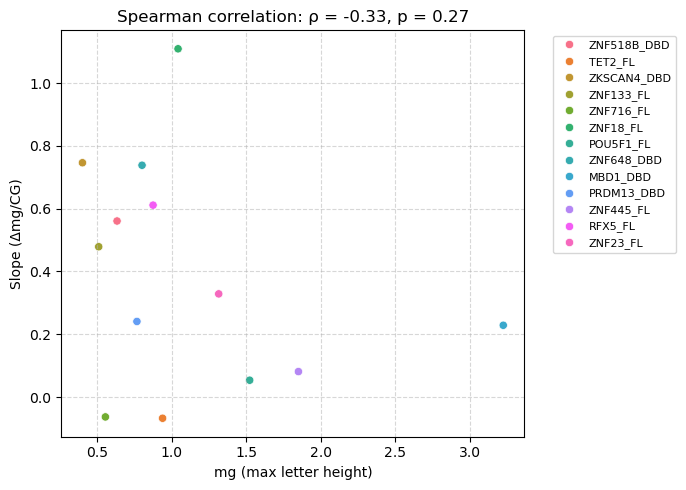

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Sample data — paste yours here directly if needed
data = {
    'TF': ['ZNF518B_DBD', 'TET2_FL', 'ZKSCAN4_DBD', 'ZNF133_FL', 'ZNF716_FL', 'ZNF18_FL',
           'POU5F1_FL', 'ZNF648_DBD', 'MBD1_DBD', 'PRDM13_DBD', 'ZNF503_DBD', 'ZNF445_FL',
           'RFX5_FL', 'ZNF23_FL'],
    'mg': [0.631639, 0.937517, 0.399266, 0.508425, 0.553436, 1.041377,
           1.522456, 0.799531, 3.225794, 0.765210, 0.197901, 1.849957,
           0.873607, 1.314484],
    'slope': [0.560691, -0.067492, 0.746217, 0.478765, -0.063258, 1.109078,
              0.053667, 0.738273, 0.228639, 0.24076, 'NA', 0.081117,
              0.61121, 0.328593]
}

df = pd.DataFrame(data)

# Convert 'slope' to numeric and drop NA
df['slope'] = pd.to_numeric(df['slope'], errors='coerce')
df_clean = df.dropna(subset=['slope'])

# Compute Spearman correlation
rho, pval = spearmanr(df_clean['mg'], df_clean['slope'])

# Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x='mg', y='slope', hue='TF')
plt.title(f"Spearman correlation: ρ = {rho:.2f}, p = {pval:.2g}")
plt.xlabel('mg (max letter height)')
plt.ylabel('Slope (Δmg/CG)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# If you don't need this, delete everything from this point

### Adding KL divergence both in single and dinucleotide context!

In [11]:
import pandas as pd
import collections
import numpy as np

In [12]:
# methylated BC is AGTA, unmethylated GAAT

In [13]:
def estimate_nucleotide_distribution(
    df, 
    seq_col, 
    methylation_col=None, 
    methylation_BC=None, 
    apply_methylation_encoding=False
):
    """
    Estimates nucleotide distribution from sequences in a DataFrame, optionally selecting only one library 
    (methylated or unmethylated) and applying CG → m/g substitution for methylated sequences.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing DNA sequences.
    seq_col : str
        Column name with 24N DNA sequences.
    methylation_col : str or None, optional
        Column name containing molecular barcodes identifying methylation state.
    methylation_BC : str or None, optional
        The barcode value identifying the library species to analyze (e.g. 'AGTA' or 'GAAT').
    apply_methylation_encoding : bool, optional
        If True and methylation_BC is selected, CG dinucleotides will be converted to 'm'/'g'.
        Default is True.

    Returns
    -------
    pd.Series
        Normalized nucleotide frequencies (A, C, G, T, m, g as applicable).
    """
    all_nucs = []

    # Filter by methylation barcode if specified
    if methylation_col and methylation_BC:
        df = df[df[methylation_col] == methylation_BC]

    for seq in df[seq_col].dropna():
        seq = seq.upper()

        if apply_methylation_encoding and methylation_col and methylation_BC:
            # Replace CG with m/g for methylated sequences
            i = 0
            while i < len(seq) - 1:
                if seq[i:i+2] == 'CG':
                    all_nucs.extend(['m', 'g'])
                    i += 2
                else:
                    all_nucs.append(seq[i])
                    i += 1
            if i == len(seq) - 1:
                all_nucs.append(seq[-1])
        else:
            all_nucs.extend(seq)

    counts = collections.Counter(all_nucs)
    total = sum(counts.values())

    return pd.Series({k: v / total for k, v in sorted(counts.items())})

In [14]:
def estimate_dinucleotide_distribution(
    df, 
    seq_col, 
    methylation_col=None, 
    methylation_BC=None, 
    apply_methylation_encoding=False
    ):
    """
    Estimates dinucleotide distribution (including methylation-aware 'mg').

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing DNA sequences.
    seq_col : str
        Name of the column with DNA sequences.
    methylation_col : str or None, optional
        Column indicating molecular barcode for methylation (optional).
    methylation_BC : str or None, optional
        Barcode value identifying methylated sequences.

    Returns
    -------
    pd.Series
        Normalized dinucleotide frequencies (e.g., AA, AT, mg, gA, etc.)
    """
    dinucs = []

    for _, row in df.iterrows():
        seq = row[seq_col].upper()

        mod_seq = []
        i = 0
        if apply_methylation_encoding and methylation_col and methylation_BC and row.get(methylation_col) == methylation_BC:
            while i < len(seq) - 1:
                if seq[i:i+2] == 'CG':
                    mod_seq.extend(['m', 'g'])
                    i += 2
                else:
                    mod_seq.append(seq[i])
                    i += 1
            if i == len(seq) - 1:
                mod_seq.append(seq[-1])
        else:
            mod_seq = list(seq)

        for i in range(len(mod_seq) - 1):
            dinucs.append(mod_seq[i] + mod_seq[i + 1])

    counts = collections.Counter(dinucs)
    total = sum(counts.values())
    return pd.Series({k: v / total for k, v in counts.items()})

In [15]:
def compute_kl_divergence(ppm: pd.DataFrame, background: pd.Series) -> pd.Series:
    """
    Computes KL divergence at each position in a Position Probability Matrix (PPM),
    relative to a given background distribution. Supports both standard (A, C, G, T)
    and extended (e.g., m, g) alphabets.

    Parameters
    ----------
    ppm : pd.DataFrame
        Position Probability Matrix (rows: positions, columns: nucleotides).
        Columns can include A, C, G, T, and optionally m, g.

    background : pd.Series
        Background nucleotide distribution. Index must match all columns of `ppm`.
        For example: ['A', 'C', 'G', 'T', 'm', 'g'] if using an extended alphabet.

    Returns
    -------
    pd.Series
        KL divergence per position (indexed like `ppm`).
    """
    # Ensure background includes all bases in the PPM
    bases = [base for base in ppm.columns if base in background.index]
    ppm = ppm[bases].copy()
    background = background[bases]

    kl_div = []

    for i, row in ppm.iterrows():
        kl = 0
        for base in bases:
            p = row[base]
            q = background[base]

            if p > 0 and q > 0:
                kl += p * np.log2(p / q)
        kl_div.append(kl)

    return pd.Series(kl_div, index=ppm.index, name='KL_divergence')


In [18]:
def plot_kl_divergence(kl_series, threshold_minor=0.1, threshold_major=0.3, ax=None, title="KL divergence per position"):
    """
    Plot KL divergence values per position with reference threshold lines.

    Parameters
    ----------
    kl_series : pd.Series
        KL divergence per position (index = position, values = KL values).

    threshold_minor : float, optional
        Lower threshold to visualize minor information content. Default is 0.1.

    threshold_major : float, optional
        Upper threshold to visualize high information content. Default is 0.3.

    ax : matplotlib.axes.Axes, optional
        If provided, the plot is drawn on this axis. Otherwise, creates a new figure.

    title : str, optional
        Title of the plot. Default is "KL divergence per position".

    Returns
    -------
    None
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))

    # Plot KL divergence as line
    ax.plot(kl_series.index, kl_series.values, color='black', linewidth=1.2, marker='o')

    # Reference thresholds
    ax.axhline(threshold_minor, linestyle=':', color='gray', label=f'{threshold_minor} (minor info)')
    ax.axhline(threshold_major, linestyle='--', color='red', label=f'{threshold_major} (major info)')

    # Axis labels and title
    ax.set_xlabel("Position", fontsize=10)
    ax.set_ylabel("KL Divergence", fontsize=10)
    ax.set_title(title, fontsize=11)

    # Format ticks and spines
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Show legend if standalone
    if ax is None:
        ax.legend(frameon=False, fontsize=8)

    if ax is None:
        plt.tight_layout()
        plt.show()


# Oke now hard test, PRDM13

In [297]:
TF = 'PRDM13_DBD'
data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
sep_matrices_path = os.path.join(data_path, 'separated/matrices/')

# Search and read all the data
files_joint = os.listdir(joint_matrices_path)
ratios = [f for f in files_joint if f.endswith('ratios.csv')]
pvals = [f for f in files_joint if f.endswith('significant.csv')]
dGGs = [f for f in files_joint if f.endswith('bindingmode_1.csv')]

files_sep = os.listdir(sep_matrices_path)
meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]


# Read the data

ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
if not pvals:
    pval = None
    significant_kmer_count = 0
    alert = 'No significant kmers!'
else:
    try:
        pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
        significant_kmer_count = len(pval)
        alert = None
    except FileNotFoundError:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'

dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

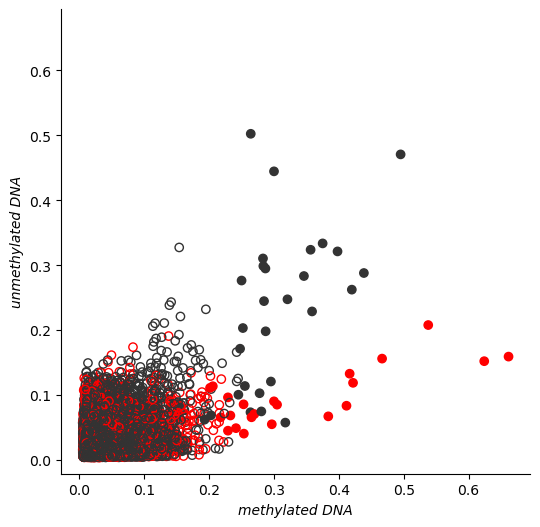

<Axes: xlabel='methylated DNA', ylabel='unmethylated DNA'>

In [298]:
utils.kmer_scatterplots(ratio_df=ratio, coords=None, ax=None)

In [303]:
def kmer_scatterplots(ratio_df, coords=None, ax=None, figsize=(5.5, 5.5)):
    """
    Plot methylated vs. unmethylated DNA elution ratios for enriched kmers,
    with better axis spacing for visual clarity.
    """
    import matplotlib.pyplot as plt

    # Color definitions
    black = '#000000'
    lightblack = '#333333'
    darkred = '#FF0000'
    lightred = '#FF6666'

    ratios = ratio_df
    x = ratios['eluted_methl']
    y = ratios['eluted_nonmethl']

    # Colors
    edgecolors = ratios['CpG'].map({True: darkred, False: lightblack})
    facecolors = [
        edgecolors.iloc[i] if sig else 'None'
        for i, sig in enumerate(ratios['fill_plot'])
    ]

    # Create axis if needed
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    # Scatter plot
    ax.scatter(x=x, y=y, facecolors=facecolors, edgecolors=edgecolors, rasterized=True)

    # Regression lines
    if coords:
        if 'with_CG' in coords:
            ax.plot(coords['with_CG']['x'], coords['with_CG']['y'], color=darkred)
        if 'no_CG' in coords:
            ax.plot(coords['no_CG']['x'], coords['no_CG']['y'], color=lightblack)

    # Aesthetics
    ax.grid(visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_aspect('equal', adjustable='box')

    # Smart axis limits
    min_val = min(x.min(), y.min())
    #lower_limit = min_val - 0.5
    max_val = max(x.max(), y.max())
    #data_range = max_val - min_val if max_val != min_val else 1  # avoid zero division
    #buffer = data_range * buffer_frac


    lower_limit = min_val - (max_val * 0.05)
    upper_limit = max_val * 1.05

    ax.set_xlim(lower_limit, upper_limit)
    ax.set_ylim(lower_limit, upper_limit)

    ax.set_xlabel('methylated DNA', fontfamily='sans-serif', fontsize=10, fontstyle='italic')
    ax.set_ylabel('unmethylated DNA', fontfamily='sans-serif', fontsize=10, fontstyle='italic')

    if created_fig:
        plt.tight_layout()
        plt.show()

    return ax

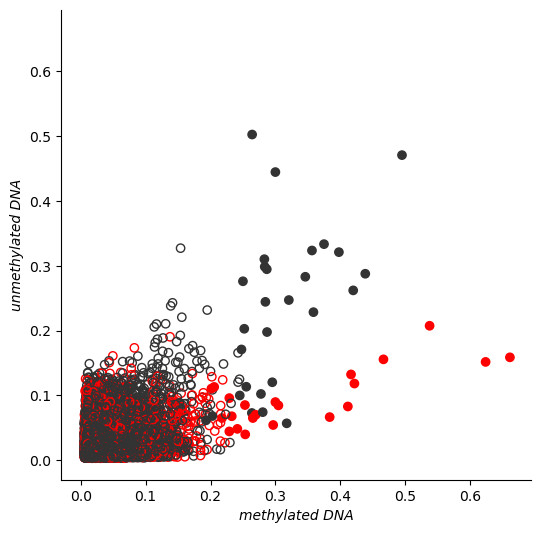

<Axes: xlabel='methylated DNA', ylabel='unmethylated DNA'>

In [304]:
kmer_scatterplots(ratio_df=ratio, coords=None, ax=None)

In [110]:
# First check background, PRDM13, SmSAG18, BC10
BC10_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230503_input/00_read_in_data/output/BC10_contamination_filtered.csv'
)
PRDM13_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/SmSAG18/00_read_in_data/output/BC10_contamination_filtered.csv'
)

In [18]:
in_m = BC10_in[BC10_in['methl'] == 'AGTA'].reset_index(drop=True)
in_nm = BC10_in[BC10_in['methl'] == 'GAAT'].reset_index(drop=True)

P13_m = PRDM13_in[PRDM13_in['methl'] == 'AGTA'].reset_index(drop=True)
P13_nm = PRDM13_in[PRDM13_in['methl'] == 'GAAT'].reset_index(drop=True)

In [19]:
# background mononucleotides
m_mono_back = estimate_nucleotide_distribution(
    df = in_m,
    seq_col = 'random24'
)
NM_mono_back = estimate_nucleotide_distribution(
    df = in_nm,
    seq_col = 'random24'
)

In [197]:
print(dGGm)
psam_m = ddG_to_psam(dGGm)
ppm_m = pfm_to_ppm(psam_m)

           A         C         G         T
0  -0.417885 -0.404309 -0.286395 -0.211890
1  -0.694438 -0.051156 -0.568718 -0.006165
2   0.096523 -0.966177 -0.072147 -0.378677
3   0.363318 -1.212461  0.448953 -0.920288
4  -1.008701  1.537505 -1.187437 -0.661844
5  -0.261695 -0.713737 -0.008392 -0.336655
6  -0.744240 -1.001879  1.520845 -1.095204
7  -0.922507 -0.994167  1.655556 -1.059360
8  -0.855383 -1.237142 -0.879302  1.651349
9  -0.228258 -0.985652  0.860359 -0.966927
10 -0.826910 -0.323251  0.480431 -0.650748
11 -0.800006  0.270434 -0.639181 -0.151725


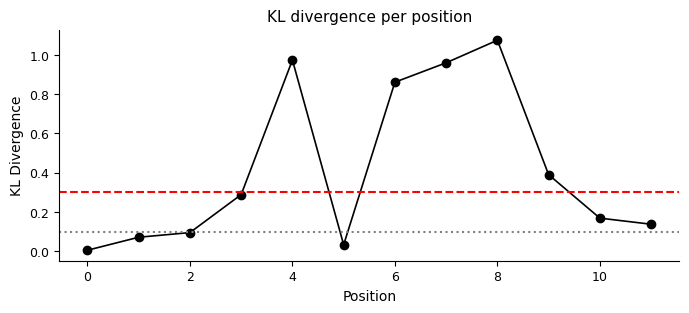

In [201]:
# mono
kl_m = compute_kl_divergence(ppm=ppm_m, background=m_mono_back)
plot_kl_divergence(kl_m)

In [ ]:
# First check background of dinucleotides
methylated_background = estimate_dinucleotide_distribution(
    df=in_m,
    seq_col='random24',
    methylation_col='methl',
    methylation_BC='AGTA',
    apply_methylation_encoding=False
)
unmethylated_background = estimate_dinucleotide_distribution(
    df=in_nm,
    seq_col='random24',
    methylation_col='methl',
    methylation_BC='GAAT',
    apply_methylation_encoding=False
)

In [102]:
# Second check prob in elution (
methylated_elu = estimate_dinucleotide_distribution(
    df=P13_m,
    seq_col='random24',
    methylation_col='methl',
    methylation_BC='AGTA',
    apply_methylation_encoding=False
)
unmethylated_elu = estimate_dinucleotide_distribution(
    df=P13_nm,
    seq_col='random24',
    methylation_col='methl',
    methylation_BC='GAAT',
    apply_methylation_encoding=False
)

In [106]:
psam_m = ddG_to_psam(dGGm)
ppm_m = pfm_to_ppm(psam_m)

Take the psam and create a pseudo dinucleotide psam as a proxy, using actual dinucleotide probabilities

In [ ]:
# Cereate Proxy Dinuc with eluted backgrounds!
df1 = ddG_to_psam(dGGm)
vector1 = methylated_elu
# Create empty df2
positions = len(df1) - 1
dinucleotides = vector1.index.tolist()
df2 = pd.DataFrame(0.0, index=range(positions), columns=dinucleotides)

# Fill df2
for i in range(positions):
    for dinuc in dinucleotides:
        first, second = dinuc[0], dinuc[1]
        val = df1[first][i] * df1[second][i + 1] * vector1[dinuc]
        df2.at[i, dinuc] = val

In [138]:
def consensus_from_dinuc_matrix(dinuc_df):
    """
    Reconstructs a consensus sequence from a dinucleotide matrix.

    Parameters:
    - dinuc_df: pd.DataFrame with rows = positions (0 to L-2), columns = dinucleotides (e.g., "AA", "AC", ..., "TT")

    Returns:
    - consensus_seq: str
    """
    consensus_seq = ""

    # Step 1: pick the dinucleotide with highest probability at position 0
    first_dinuc = dinuc_df.iloc[0].idxmax()
    consensus_seq += first_dinuc  # adds both letters

    # Step 2: iterate over the rest of the positions
    for i in range(1, len(dinuc_df)):
        last_base = consensus_seq[-1]
        # Find dinucleotides starting with last_base
        candidates = dinuc_df.iloc[i][[d for d in dinuc_df.columns if d.startswith(last_base)]]

        if not candidates.empty:
            next_dinuc = candidates.idxmax()
            consensus_seq += next_dinuc[1]  # append the second base
        else:
            # fallback: pick max dinuc regardless of continuity
            next_dinuc = dinuc_df.iloc[i].idxmax()
            consensus_seq += next_dinuc[1]

    return consensus_seq

In [139]:
consensus_from_dinuc_matrix(df2)

'GTGGCGGGTGGC'

In [140]:
def dinuc_KL_divergence(motif_df, background_series, pseudocount=1e-9):
    """
    Compute DKL per position for dinucleotide motif matrix vs background.
    
    Parameters:
    - motif_df: pd.DataFrame with dinucleotides as columns and positions as rows
    - background_series: pd.Series with dinucleotide frequencies (must include same keys as motif_df.columns)
    - pseudocount: small value to avoid division by zero
    
    Returns:
    - pd.Series with DKL per position
    """
    # Ensure all probabilities are positive
    P = motif_df + pseudocount
    Q = background_series[motif_df.columns] + pseudocount  # align and avoid missing keys

    # Normalize motif matrix rows
    P = P.div(P.sum(axis=1), axis=0)

    # Compute log2(P / Q) for each dinuc
    log_ratio = np.log2(P / Q)

    # Compute DKL per row
    DKL = (P * log_ratio).sum(axis=1)

    return DKL

In [147]:
normal_df2 = df2.div(df2.sum(axis=1), axis=0)

In [159]:
a = dinuc_KL_divergence(normal_df2, methylated_background)

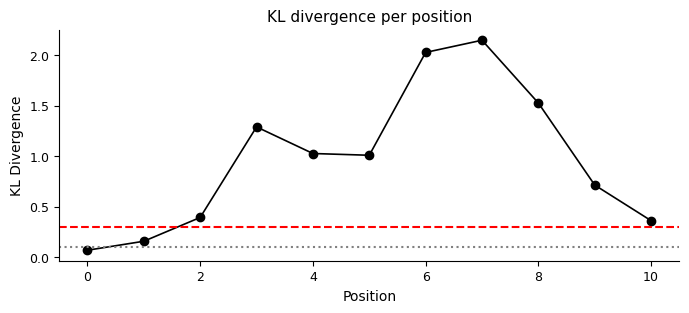

In [160]:
plot_kl_divergence(a)

Try with proxy background distr

In [169]:
import random
from collections import defaultdict

def sample_start_base(dinuc_probs):
    """Randomly choose a starting base based on marginal dinucleotide frequencies."""
    base_counts = defaultdict(float)
    for dinuc, prob in dinuc_probs.items():
        base_counts[dinuc[0]] += prob
    bases, weights = zip(*base_counts.items())
    return np.random.choice(bases, p=np.array(weights)/sum(weights))

def generate_sequence(dinuc_probs, length):
    """Generate a sequence of length `length + 1` so we have `length` dinucleotides."""
    seq = [sample_start_base(dinuc_probs)]
    for _ in range(length):
        prev_base = seq[-1]
        # collect possible next bases
        options = [(d[1], p) for d, p in dinuc_probs.items() if d[0] == prev_base]
        if not options:
            # fallback to uniform
            next_base = random.choice(["A", "C", "G", "T"])
        else:
            bases, probs = zip(*options)
            probs = np.array(probs) / sum(probs)
            next_base = np.random.choice(bases, p=probs)
        seq.append(next_base)
    return ''.join(seq)

def generate_dinuc_matrix(dinuc_probs, positions=12, n_sequences=10000):
    """
    Generate a dinucleotide probability matrix from simulated sequences.
    
    Returns:
    pd.DataFrame with shape (positions, 16 dinucleotides)
    """
    dinucleotides = [a + b for a in "ACGT" for b in "ACGT"]
    counts = {pos: defaultdict(int) for pos in range(positions)}

    for _ in range(n_sequences):
        seq = generate_sequence(dinuc_probs, positions)
        for i in range(positions):
            dinuc = seq[i:i+2]
            if len(dinuc) == 2:
                counts[i][dinuc] += 1

    # Convert to DataFrame
    df = pd.DataFrame([
        {dinuc: counts[pos].get(dinuc, 0) for dinuc in dinucleotides}
        for pos in range(positions)
    ])

    # Normalize rows
    df = df.div(df.sum(axis=1), axis=0)
    return df

In [179]:
background_matrix = generate_dinuc_matrix(methylated_background, positions=11, n_sequences=10000)

In [181]:
consensus_from_dinuc_matrix(background_matrix)

'GGGGGGGGCGGG'

In [182]:
len(background_matrix)

11

In [184]:
kl_m = calculate_dkl_per_position(normal_df2, background_matrix)

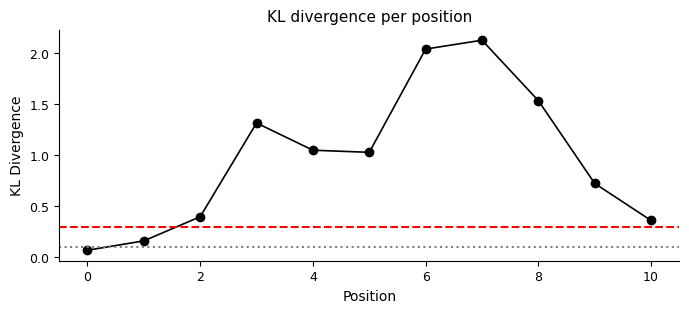

In [185]:
plot_kl_divergence(kl_m)

In [164]:
normal_back = background_df.div(background_df.sum(axis=1), axis=0)

In [166]:
calculate_dkl_per_position(normal_df2, normal_back)

0     0.002698
1     0.002203
2     0.002528
3     0.001649
4     0.001810
5     0.002047
6     0.001540
7     0.001888
8     0.001505
9     0.002505
10    0.002409
dtype: float64

In [89]:
kl_m = compute_kl_divergence(ppm=ppm_m, background=methylated_background)

In [92]:
#unmethylated
psam_um = ddG_to_psam(dGGum)
ppm_um = pfm_to_ppm(psam_um)

### Testing different metrics
I use dGGm and ppm_m and m_mono_back as background

In [212]:
kl = kl_divergence(ppm_m, back_mat)
jsd = jensen_shannon_divergence(ppm_m, back_mat)
eu = euclidean_distance(ppm_m, back_mat)

In [54]:
def kl_divergence(P: pd.DataFrame, Q: pd.DataFrame) -> pd.Series:
    """Per-position Kullback-Leibler divergence (P || Q)"""
    P = P.replace(0, 1e-10)
    Q = Q.replace(0, 1e-10)
    return (P * np.log2(P / Q)).sum(axis=1)

def jensen_shannon_divergence(P: pd.DataFrame, Q: pd.DataFrame) -> pd.Series:
    """Per-position Jensen-Shannon divergence"""
    P = P.replace(0, 1e-10)
    Q = Q.replace(0, 1e-10)
    M = 0.5 * (P + Q)
    return 0.5 * (P * np.log2(P / M)).sum(axis=1) + 0.5 * (Q * np.log2(Q / M)).sum(axis=1)

def euclidean_distance(P: pd.DataFrame, Q: pd.DataFrame) -> pd.Series:
    """Per-position Euclidean distance"""
    return np.sqrt(((P - Q) ** 2).sum(axis=1))

def total_divergence(metric_fn, P: pd.DataFrame, Q: pd.DataFrame) -> float:
    return metric_fn(P, Q).sum()

def generate_random_motif(bg_df: pd.DataFrame, alpha_scale: float = 100.) -> pd.DataFrame:
    """Sample a NEW motif each call; rows sum to 1."""
    dinucs = bg_df.columns
    base_alpha = bg_df.iloc[0].to_numpy() * alpha_scale   # alpha > 0
    rnd_rows = [np.random.dirichlet(base_alpha) for _ in range(len(bg_df))]
    return pd.DataFrame(rnd_rows, columns=dinucs)

def empirical_p_value(observed_motif: pd.DataFrame,
                      bg_df: pd.DataFrame,
                      N: int = 1000):
    obs_kl  = kl_divergence(observed_motif, bg_df)
    null_kls = []
    for _ in range(N):
        rnd = generate_random_motif(bg_df)
        null_kls.append(kl_divergence(rnd, bg_df))
    p = np.mean([d >= obs_kl for d in null_kls])
    return p, obs_kl, null_kls

def expand_flat_background(flat_background: pd.Series, n_positions: int) -> pd.DataFrame:
    """
    Expand a flat background distribution to match the number of motif positions.
    
    Parameters
    ----------
    flat_background : pd.Series
        Background distribution (dinucleotide probabilities)
    n_positions : int
        Number of positions in the motif

    Returns
    -------
    pd.DataFrame
        Repeated background matrix of shape (n_positions, len(flat_background))
    """
    flat_background = flat_background.replace(0, 1e-10)
    return pd.DataFrame([flat_background.values] * n_positions, columns=flat_background.index)


def plot_null_distribution(null_scores, observed_score, title='KL divergence'):
    plt.hist(null_scores, bins=50, color='gray', alpha=0.6)
    plt.axvline(observed_score, color='red', linestyle='--', label=f'Observed = {observed_score:.3f}')
    plt.xlabel('Divergence Score')
    plt.ylabel('Count')
    plt.title(f'Null Distribution of {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [28]:
psam_m = ddG_to_psam(dGGm)
ppm_m = pfm_to_ppm(psam_m)

In [29]:
psam_um = ddG_to_psam(dGGum) 
ppm_um = pfm_to_ppm(psam_um)

In [30]:
ppm_um

,A,C,G,T
0,0.239135,0.245042,0.275049,0.240774
1,0.207042,0.290220,0.179348,0.323390
2,0.360031,0.141177,0.290589,0.208204
3,0.387630,0.076024,0.464720,0.071626
4,0.076267,0.754093,0.092554,0.077086
5,0.362021,0.099983,0.172731,0.365265
6,0.100571,0.053139,0.772956,0.073335
7,0.049202,0.069767,0.811760,0.069271
8,0.068934,0.049016,0.070616,0.811434
9,0.198605,0.114783,0.591793,0.094818


In [31]:
diff = ppm_m - ppm_um

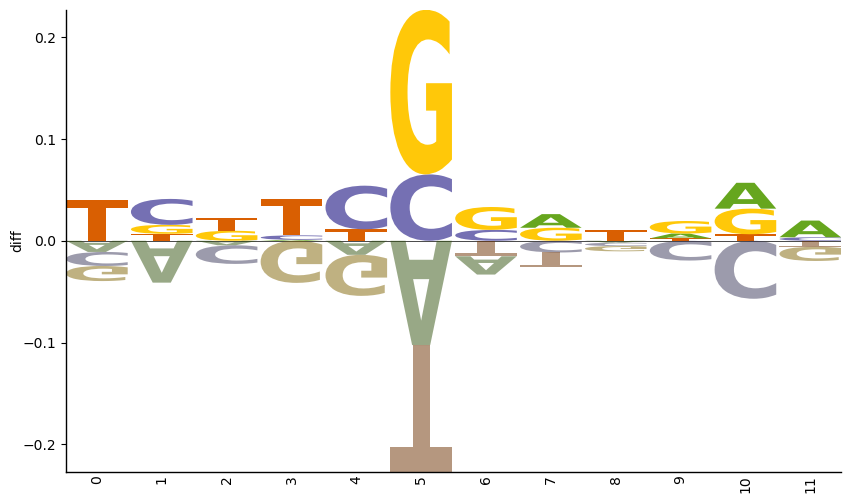

In [32]:
fig, ax = plt.subplots(1,1,figsize=[10,6])
logo = logomaker.Logo(diff,
                    shade_below=0.5,
                    ax=ax,
                    fade_below=0.5,
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=90, fmt='%d', anchor=0)

# style using Axes methods
logo.ax.set_ylabel("diff", labelpad=-1)
logo.ax.xaxis.set_ticks_position('none')
logo.ax.xaxis.set_tick_params(pad=-1)
plt.show()

In [51]:
test_jsd = jensen_shannon_divergence(ppm_m, ppm_um)

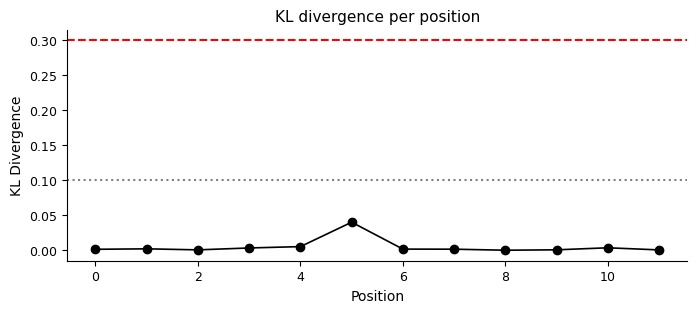

In [52]:
plot_kl_divergence(test_jsd)

In [34]:
#KL divergence on diff
print(m_mono_back)
print(NM_mono_back)

A    0.237959
C    0.246768
G    0.271937
T    0.243336
dtype: float64
A    0.236247
C    0.247359
G    0.272312
T    0.244082
dtype: float64


In [241]:
diff_bk = m_mono_back - NM_mono_back

In [242]:
diff_bk

A    0.001712
C   -0.000591
G   -0.000375
T   -0.000746
dtype: float64

In [38]:
in_nm.head()

,methl,BC,lfl,random24,rfl
0,GAAT,GATTGGT,TA,TCTCTGAATTATCAATTCAAGCCT,TAGAG
1,GAAT,GATTGGT,TA,GAAACACTGGACCGTAAGCAGCCT,TAGAG
2,GAAT,GATTGGT,TA,ATAGTCGGGATTGCCCGAGTGACT,TAGAG
3,GAAT,GATTGGT,TA,CTGTATTAGCTTATTGGAATTTAC,TAGAG
4,GAAT,GATTGGT,TA,CGGATGCGAACTGGAACACTTTCT,TAGAG


# Trying with ZNF23

In [4]:
TF = 'ZNF23_FL'
data_path = f'/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_motifs_and_scatterplots_for_publication/{TF}/'
joint_matrices_path = os.path.join(data_path, 'joint/matrices/')
    
sep_matrices_path = os.path.join(data_path, 'separated/matrices/')

# Search and read all the data
files_joint = os.listdir(joint_matrices_path)
ratios = [f for f in files_joint if f.endswith('ratios.csv')]
pvals = [f for f in files_joint if f.endswith('significant.csv')]
dGGs = [f for f in files_joint if f.endswith('bindingmode_1.csv')]

files_sep = os.listdir(sep_matrices_path)
meths = [f for f in files_sep if f.endswith('_methylated_bindingmode_1.csv')]
unmeths = [f for f in files_sep if f.endswith('_unmethylated_bindingmode_1.csv')]


# Read the data

ratio = pd.read_csv(os.path.join(joint_matrices_path, ratios[0]), index_col=0)
if not pvals:
    pval = None
    significant_kmer_count = 0
    alert = 'No significant kmers!'
else:
    try:
        pval = pd.read_csv(os.path.join(joint_matrices_path,pvals[0]))
        significant_kmer_count = len(pval)
        alert = None
    except FileNotFoundError:
        pval = None
        significant_kmer_count = 0
        alert = 'No significant kmers!'

dGGj = pd.read_csv(os.path.join(joint_matrices_path, dGGs[0]), index_col=0)

dGGm = pd.read_csv(os.path.join(sep_matrices_path, meths[0]), index_col=0)
dGGum = pd.read_csv(os.path.join(sep_matrices_path, unmeths[0]), index_col=0)

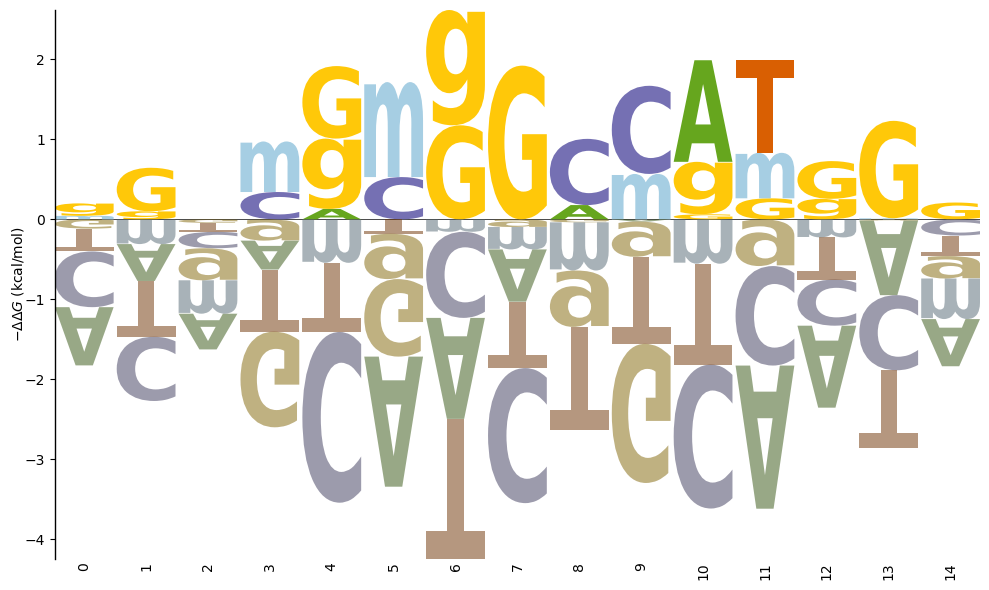

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [10]:
utils.make_logo(utils.rev_complement(dGGj))

In [19]:
psam_m = ddG_to_psam(dGGm)
ppm_m = pfm_to_ppm(psam_m)

In [20]:
psam_um = ddG_to_psam(dGGum)
ppm_um = pfm_to_ppm(psam_um)

In [21]:
# First check background, ZNF23, SmSAG16, BC10
BC10_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/inputs/20230503_input/00_read_in_data/output/BC10_contamination_filtered.csv'
)
ZNF23_in = pd.read_csv(
    '~/updepla/users/gralak/NAS2/SmileSeq_paper/SmileSeq_experiments/SmSAG16/00_read_in_data/output/BC10_contamination_filtered.csv'
)

in_m = BC10_in[BC10_in['methl'] == 'AGTA'].reset_index(drop=True)
in_nm = BC10_in[BC10_in['methl'] == 'GAAT'].reset_index(drop=True)

Z23_m = ZNF23_in[ZNF23_in['methl'] == 'AGTA'].reset_index(drop=True)
Z23_nm = ZNF23_in[ZNF23_in['methl'] == 'GAAT'].reset_index(drop=True)

# background mononucleotides
m_mono_back = estimate_nucleotide_distribution(
    df = in_m,
    seq_col = 'random24'
)
NM_mono_back = estimate_nucleotide_distribution(
    df = in_nm,
    seq_col = 'random24'
)

In [29]:
dGGm

,A,C,G,T
0,-0.435195,-0.588233,-0.193748,-0.405356
1,-0.435548,0.066726,-0.538438,-0.715272
2,-1.062486,1.211248,-0.644453,-1.126840
3,-0.509518,0.651974,-0.989951,-0.775036
4,0.824387,0.135733,-0.517805,-2.064846
5,-1.127036,0.192347,-1.835482,1.147640
6,-0.861685,-1.769661,1.081168,-0.072353
7,-1.624147,-0.227023,0.451097,-0.222458
8,-0.970299,1.819837,-1.724721,-0.747349
9,-1.338429,2.014575,-1.457860,-0.840817


In [33]:
dGGm_rev = utils.rev_complement(dGGm, extended_alphabet=False)
ppm_m_rev = utils.rev_complement(ppm_m, extended_alphabet=False)

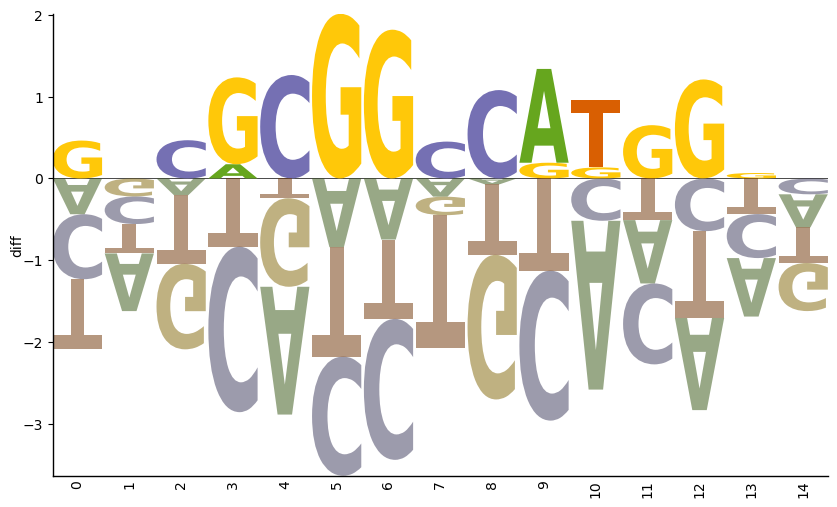

In [36]:
fig, ax = plt.subplots(1,1,figsize=[10,6])
logo = logomaker.Logo(dGGm_rev,
                    shade_below=0.5,
                    ax=ax,
                    fade_below=0.5,
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=90, fmt='%d', anchor=0)

# style using Axes methods
logo.ax.set_ylabel("diff", labelpad=-1)
logo.ax.xaxis.set_ticks_position('none')
logo.ax.xaxis.set_tick_params(pad=-1)
plt.show()

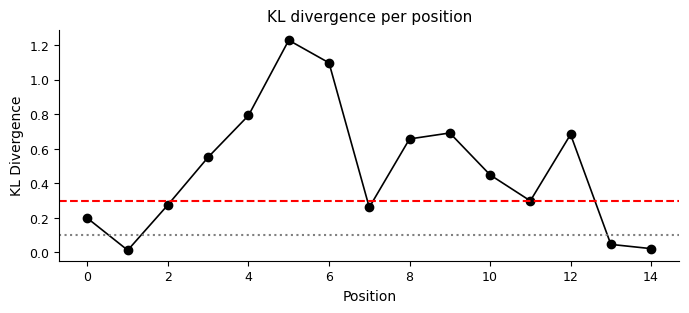

In [34]:
# mono
kl_m = compute_kl_divergence(ppm=ppm_m_rev, background=m_mono_back)
plot_kl_divergence(kl_m)

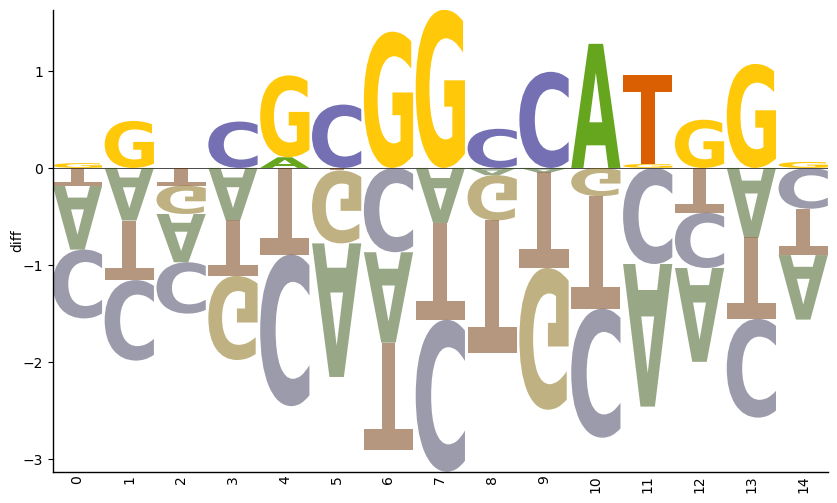

In [37]:
fig, ax = plt.subplots(1,1,figsize=[10,6])
logo = logomaker.Logo(dGGum,
                    shade_below=0.5,
                    ax=ax,
                    fade_below=0.5,
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=90, fmt='%d', anchor=0)

# style using Axes methods
logo.ax.set_ylabel("diff", labelpad=-1)
logo.ax.xaxis.set_ticks_position('none')
logo.ax.xaxis.set_tick_params(pad=-1)
plt.show()

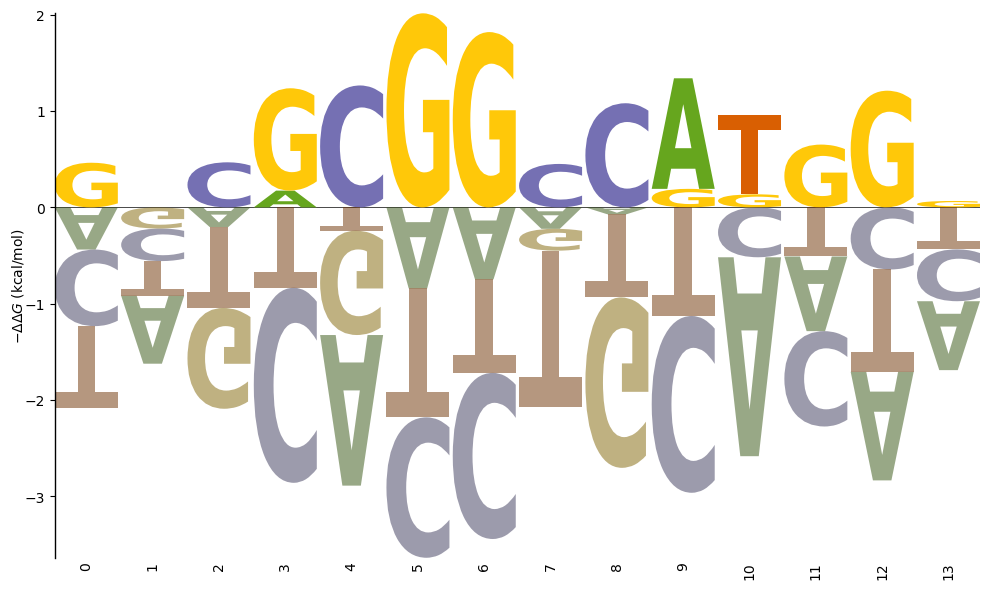

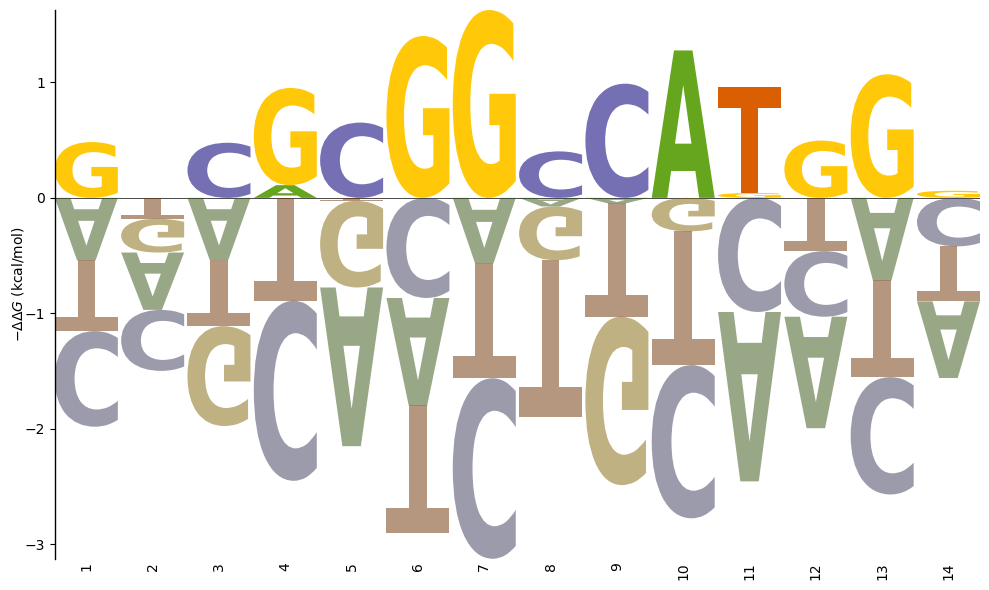

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [46]:
utils.make_logo(dGGm_rev.drop(index=14))
utils.make_logo(dGGum.drop(index=0))

In [57]:
#align
meth = ppm_m_rev.drop(index=14).reset_index(drop=True)
no_meth = ppm_um.drop(index=0).reset_index(drop=True)

In [58]:
diff = meth - no_meth

In [59]:
diff

,A,C,G,T
0,0.024555,0.007931,0.000900,-0.033386
1,-0.036578,0.051253,0.027851,-0.042526
2,0.071754,-0.007204,-0.022404,-0.042146
3,-0.019162,-0.023359,0.050142,-0.007621
4,-0.026888,0.196203,-0.061006,-0.108308
5,-0.024387,-0.052936,0.109854,-0.032531
6,-0.025166,-0.008767,0.040461,-0.006529
7,-0.042714,0.014375,0.047155,-0.018816
8,-0.016406,0.026522,-0.016519,0.006403
9,-0.079911,-0.020988,0.097899,0.003000


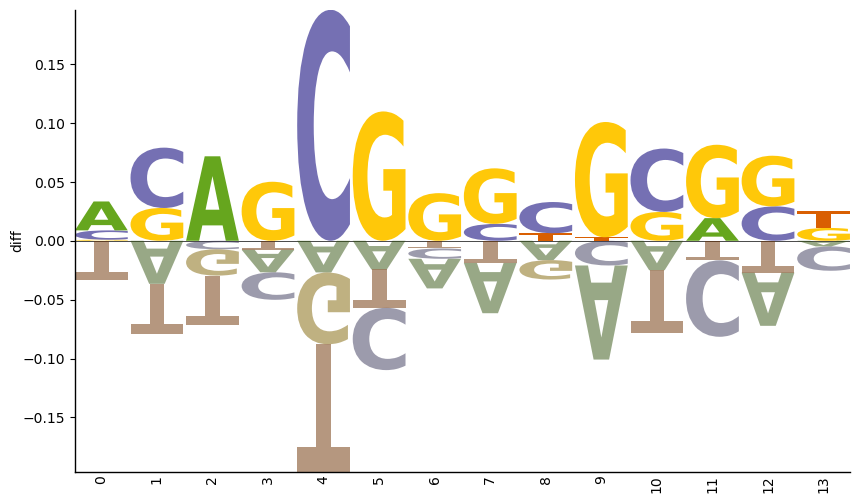

In [52]:
fig, ax = plt.subplots(1,1,figsize=[10,6])
logo = logomaker.Logo(diff,
                    shade_below=0.5,
                    ax=ax,
                    fade_below=0.5,
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=90, fmt='%d', anchor=0)

# style using Axes methods
logo.ax.set_ylabel("diff", labelpad=-1)
logo.ax.xaxis.set_ticks_position('none')
logo.ax.xaxis.set_tick_params(pad=-1)
plt.show()

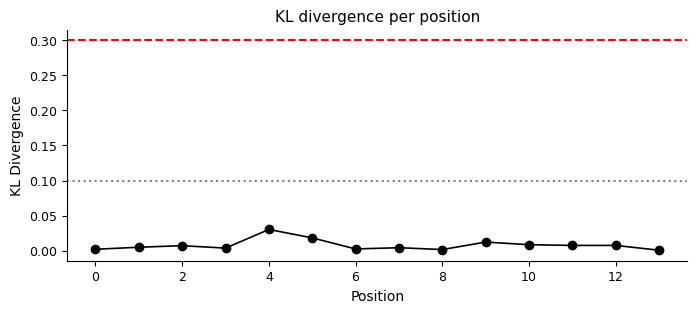

In [60]:
test_jsd = jensen_shannon_divergence(meth, no_meth)
plot_kl_divergence(test_jsd)

In [63]:
dGGj_rev = utils.rev_complement(dGGj)

In [64]:
stats_df = utils.calculate_stats2(dGGj_rev)

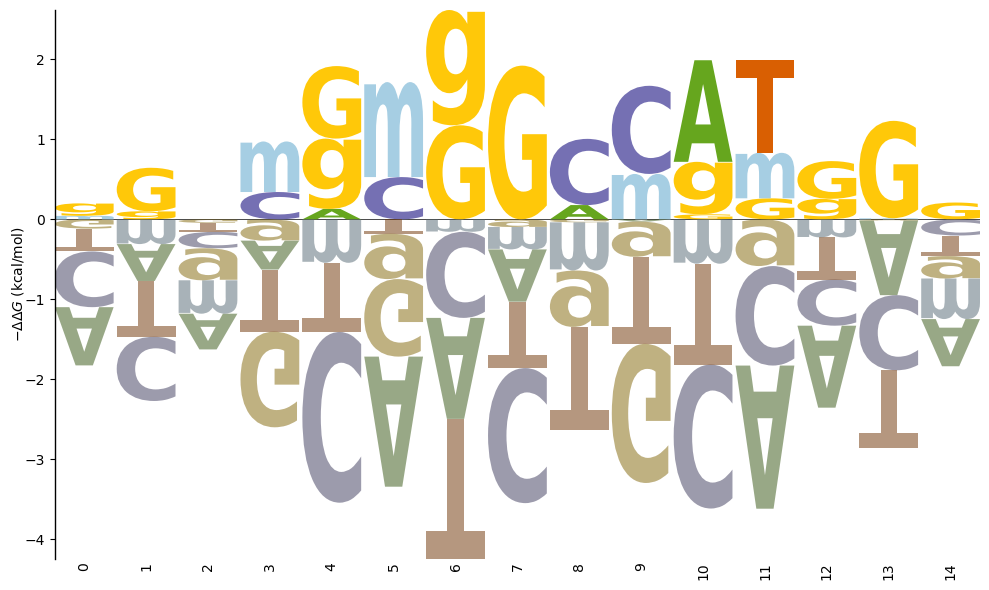

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [66]:
utils.make_logo(dGGj_rev)

In [65]:
stats_df

,CG,mg,ratio CG/mg,C%topvalue,G%topvalue,m%topvalue,g%topvalue,delta_mg-CG
0,NA,0.072381,mg available,-0.344082,0.186628,0.021734,0.034550,0.297447
1,NA,NA,not applicable,-0.275540,-0.026914,-0.106013,-0.246353,0.137509
2,NA,NA,not applicable,-0.126210,-0.334743,-0.256921,-0.074398,0.717862
3,0.624252,0.75565,0.826112,0.095652,0.166087,0.176847,0.161073,0.262797
4,NA,NA,not applicable,-0.391040,-0.191616,-0.099527,-0.112016,1.994018
5,0.852323,1.314484,0.648409,0.104516,0.171400,0.234756,0.210099,0.924322
6,NA,NA,not applicable,-0.156888,0.351357,-0.022673,-0.017497,-1.096674
7,NA,NA,not applicable,-0.308751,-0.010278,-0.051222,-0.193743,0.741011
8,NA,NA,not applicable,0.227486,-0.350401,-0.165483,-0.088849,-0.131123
9,0.582794,0.61176,0.952651,0.221910,0.011351,0.114365,0.116975,0.057933


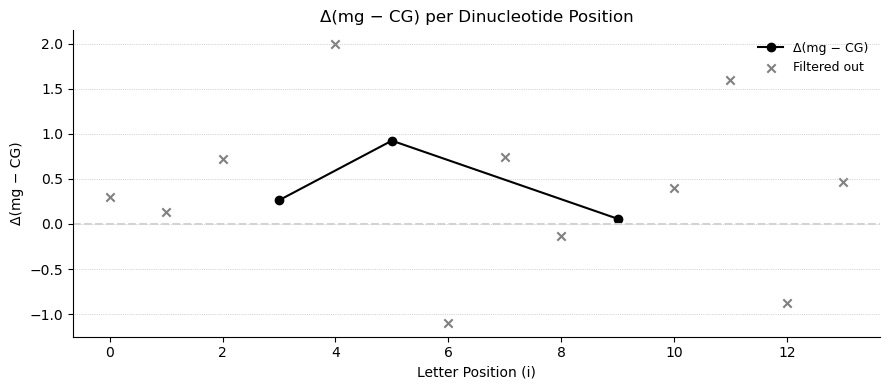

<Axes: title={'center': 'Δ(mg − CG) per Dinucleotide Position'}, xlabel='Letter Position (i)', ylabel='Δ(mg − CG)'>

In [67]:
utils.plot_delta_mg_CG_context_aware(stats_df=stats_df)

In [70]:
psam_j = utils.ddG_to_psam(dGGj_rev)
ppm_j = utils.pfm_to_ppm(psam_j)

In [72]:
stats_df_test = utils.calculate_stats2(ppm_j)

In [83]:
ppm_j

,A,C,G,T,m,g
0,0.099834,0.102984,0.184136,0.155456,0.216042,0.241549
1,0.122684,0.087123,0.335284,0.096887,0.142830,0.215192
2,0.138078,0.175765,0.206564,0.192907,0.142111,0.144574
3,0.126306,0.255242,0.054822,0.083455,0.341171,0.139004
4,0.159468,0.016554,0.346543,0.058958,0.081290,0.337186
5,0.028279,0.243981,0.054551,0.120103,0.471491,0.081596
6,0.031018,0.037363,0.355330,0.019069,0.093835,0.463385
7,0.053968,0.019167,0.708937,0.045254,0.078397,0.094278
8,0.207392,0.396942,0.167102,0.047853,0.094997,0.085714
9,0.141007,0.435998,0.025423,0.048805,0.255594,0.093173


In [73]:
stats_df_test

,CG,mg,ratio CG/mg,C%topvalue,G%topvalue,m%topvalue,g%topvalue,delta_mg-CG
0,0.219134,0.215617,1.016314,0.102984,0.335284,0.216042,0.215192,-0.007035
1,0.146844,0.143702,1.021864,0.087123,0.206564,0.142830,0.144574,-0.006284
2,0.115294,0.140557,0.820262,0.175765,0.054822,0.142111,0.139004,0.050527
3,0.300893,0.339179,0.887122,0.255242,0.346543,0.341171,0.337186,0.076571
4,0.035552,0.081443,0.436533,0.016554,0.054551,0.081290,0.081596,0.091781
5,0.299655,0.467438,0.641059,0.243981,0.355330,0.471491,0.463385,0.335565
6,0.373150,0.094056,3.967306,0.037363,0.708937,0.093835,0.094278,-0.558188
7,0.093135,0.082055,1.135023,0.019167,0.167102,0.078397,0.085714,-0.022159
8,0.211182,0.094085,2.244587,0.396942,0.025423,0.094997,0.093173,-0.234194
9,0.288331,0.254927,1.131036,0.435998,0.140664,0.255594,0.254259,-0.066809


In [84]:
def logo(df):
    logo = logomaker.Logo(df,
                shade_below=0.5,
                fade_below=0.5,
                color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'},
                stack_order = 'small_on_top'
                    #baseline_width=0
                )

    # style using Logo methods
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    logo.style_xticks(rotation=90, fmt='%d', anchor=0)
        

        # style using Axes methods
    logo.ax.set_ylabel("$-\Delta \Delta G$ (kcal/mol)", labelpad=-1)
    logo.ax.xaxis.set_ticks_position('none')
    logo.ax.xaxis.set_tick_params(pad=-1)
        

        #plt.savefig(os.path.join(out,file.split('.')[0] + '.pdf'))
    

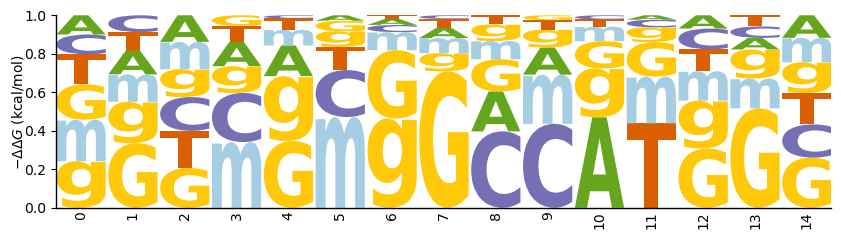

In [85]:
logo(ppm_j)

In [250]:
df = pd.read_csv('~/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_joint_analysis/SmSAG16/04_ProBound_analysis/psam/ZNF23_FL/binding_mode_size_24/ZNF23_FL_bindingmode_1.csv', index_col=0)

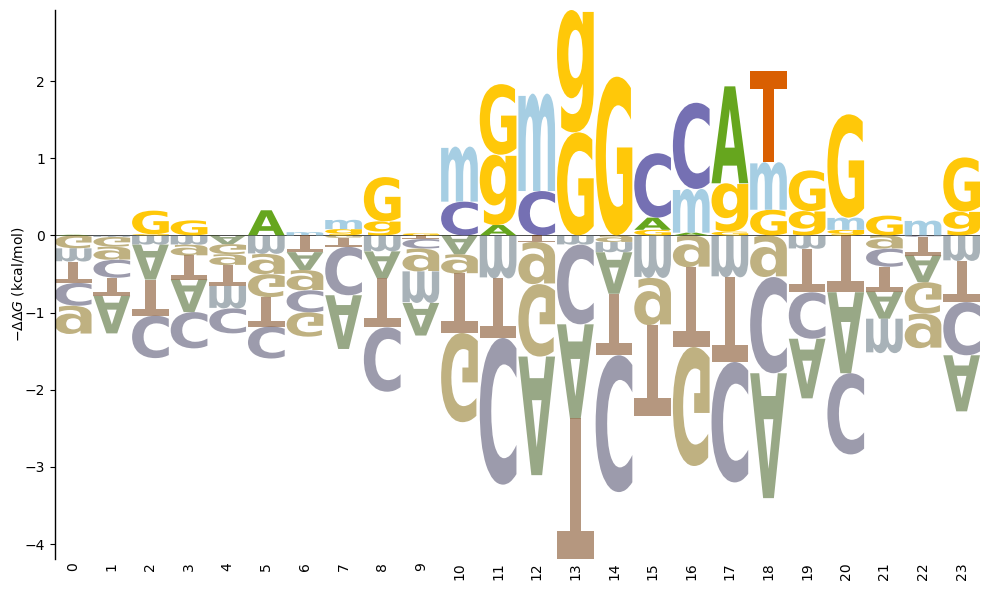

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [253]:
utils.make_logo(utils.rev_complement(df))

In [96]:
bg = BC10_in.copy()

In [100]:
bg.loc[bg['methl'] == 'AGTA', 'random24'] = bg.loc[bg['methl'] == 'AGTA', 'random24'].str.replace('CG', 'mg', regex=True)


In [105]:
bg

,methl,BC,lfl,random24,rfl
0,ATTA,GATTGGT,TA,AAGTGAGGGTATCACCTTGGGGCG,TAGAG
1,GAAT,GATTGGT,TA,TCTCTGAATTATCAATTCAAGCCT,TAGAG
2,AGTA,GATTGGT,TA,GATCTAGGAACTCTAAAGGTAAmg,TAGAG
3,GAAT,GATTGGT,TA,GAAACACTGGACCGTAAGCAGCCT,TAGAG
4,GAAT,GATTGGT,TA,ATAGTCGGGATTGCCCGAGTGACT,TAGAG
...,...,...,...,...,...
1072514,AGTA,GATTGGT,TA,TTGCCTTTAACTTmgTAACATCTC,TAGAG
1072515,GAAT,GATTGGT,TA,CTGATGAAATTCACTTTTAGAAAC,TAGAG
1072516,GAAT,GATTGGT,TA,GGATCACGCTAAGGTTATGTGTCG,TAGAG
1072517,GAAT,GATTGGT,TA,TCCAGAGTTTTAAGTACGACGAGT,TAGAG


In [103]:
bg_n = estimate_nucleotide_distribution(bg, seq_col='random24', methylation_BC='AGTA', methylation_col='methl',apply_methylation_encoding=True)

In [104]:
bg_n

A    0.237959
C    0.184674
G    0.271937
M    0.062094
T    0.243336
dtype: float64

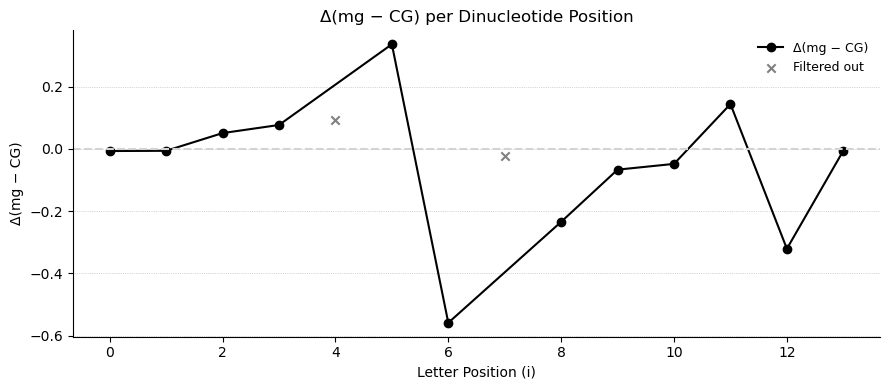

<Axes: title={'center': 'Δ(mg − CG) per Dinucleotide Position'}, xlabel='Letter Position (i)', ylabel='Δ(mg − CG)'>

In [74]:
utils.plot_delta_mg_CG_context_aware(stats_df=stats_df_test)

### Idea after discussion with Vanja, take the consensus motif, and grep the entire motif from raw data, and then estimate at 'interesting' positions the frequency of dinucleotides

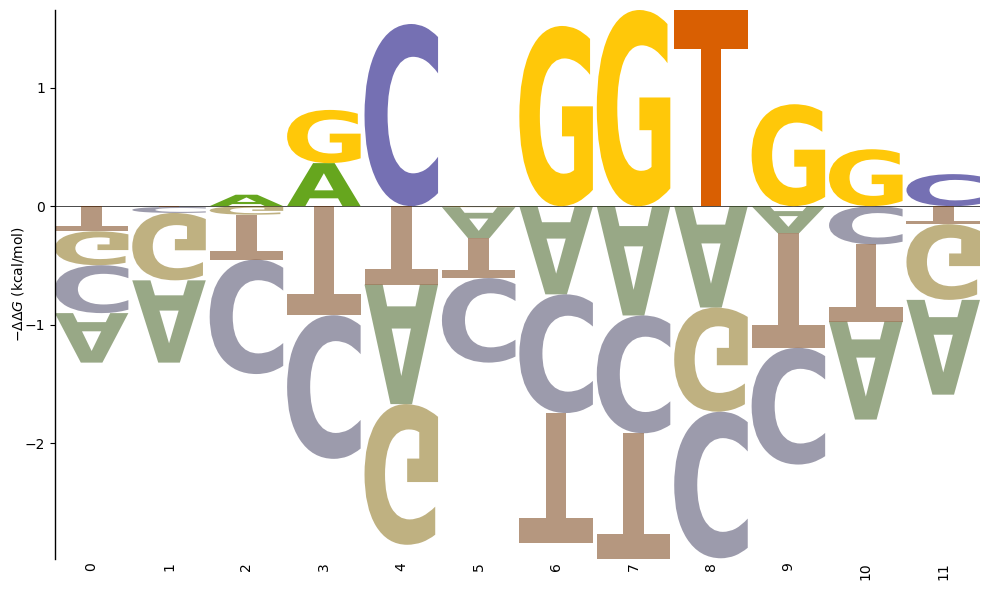

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [115]:
# Back to PRDM13
utils.make_logo(dGGm)

In [112]:

def ddg_to_consensus(ddg_df: pd.DataFrame) -> str:
    """
    Generate a consensus sequence from a -ΔΔG matrix.

    Parameters:
    - ddg_df: pandas DataFrame, shape (L, 4), where rows are positions and
              columns are nucleotides ('A', 'C', 'G', 'T').
              Higher values represent more favorable binding (e.g., -ΔΔG).

    Returns:
    - consensus: str, the consensus sequence.
    """
    consensus = ''
    for _, row in ddg_df.iterrows():
        consensus += row.idxmax()
    return consensus

In [118]:
cons_m = ddg_to_consensus(dGGm)

In [119]:
cons_m_r = utils.rev_complement_seq(cons_m)

In [128]:
print(cons_m)

TTAGCGGGTGGC


In [131]:
P13_m = PRDM13_in[PRDM13_in['methl'] == 'AGTA']

In [132]:
P13_m

,methl,BC,lfl,random24,rfl
1,AGTA,GATTGGT,TA,GGAGTTAACCGGTATCCAGATGTC,TAGAG
2,AGTA,GATTGGT,TA,TAACCACTCGGGCATCGGGCCGGT,TAGAG
4,AGTA,GATTGGT,TA,CTGGTAGGGCCATGACCACCCGGA,TAGAG
6,AGTA,GATTGGT,TA,GGAGTTAACCGGTATCCAGATGTC,TAGAG
11,AGTA,GATTGGT,TA,AATAATTGGAGTGGGACACCGAGA,TAGAG
...,...,...,...,...,...
26996,AGTA,GATTGGT,TA,TAGCAGCTCGTAACAGGGCCTGCG,TAGAG
27000,AGTA,GATTGGT,TA,AGCTGGTATCCGCAGGTGGAAAAT,TAGAG
27005,AGTA,GATTGGT,TA,GTAATCGGAAGTATGGGAGTCATA,TAGAG
27008,AGTA,GATTGGT,TA,GTAAAGTACGCGCCGGTTTACTAT,TAGAG


In [ ]:
#make kmers with length 12 cuz the psam is 12
count_table = utils.kmer_counting(P13_m, kmer=12, one_df=True)

In [139]:
count_table.loc[0,'kmer']

'GGAGTTAACCGG'

In [144]:
psam_m = utils.ddG_to_psam(dGGm)

In [140]:
count_table

,kmer,count,mod,status
0,GGAGTTAACCGG,3.0,methl,None
1,GAGTTAACCGGT,3.0,methl,None
2,AGTTAACCGGTA,3.0,methl,None
3,GTTAACCGGTAT,3.0,methl,None
4,TTAACCGGTATC,3.0,methl,None
...,...,...,...,...
87348,AAGTATGGGAGT,1.0,methl,None
87349,AGTATGGGAGTC,1.0,methl,None
87350,GTATGGGAGTCA,1.0,methl,None
87351,TATGGGAGTCAT,1.0,methl,None


In [257]:
cons_m_crop = cons_m[2:]

In [258]:
cons_m_crop

'AGCGGGTGGC'

In [263]:
cons_m_crop_rev = utils.rev_complement_seq(cons_m_crop)

In [264]:
cons_m_crop_rev

'GCCACCCGCT'

In [271]:
count_table[count_table['kmer'].str.contains(f'{cons_m_crop}|{cons_m_crop_rev}', regex=True)]['count']

14118    1.0
22641    2.0
22642    2.0
22643    2.0
23276    1.0
23277    4.0
23278    1.0
34501    2.0
34502    2.0
34503    1.0
37351    2.0
37352    2.0
37353    2.0
48874    1.0
48875    1.0
58787    1.0
58788    1.0
58789    3.0
61961    1.0
66458    1.0
66459    1.0
68160    1.0
84155    1.0
84156    1.0
86038    3.0
86039    3.0
Name: count, dtype: float64

In [272]:
psam_um

,A,C,G,T
0,0.494510,0.468525,1.000000,0.790107
1,0.358658,0.269028,1.000000,0.333905
2,0.729226,0.706497,0.894681,1.000000
3,0.361803,1.000000,0.260912,0.349849
4,0.480815,0.090421,1.000000,0.176593
5,0.131616,1.000000,0.245734,0.507663
6,0.096892,0.103264,1.000000,0.081601
7,0.111380,0.041051,1.000000,0.072453
8,0.620545,1.000000,0.419440,0.171119
9,0.354672,1.000000,0.086322,0.139182


In [196]:
def score_words_and_reverse(df, word_col, psam, score_col='score', score_rev_col='score_rev'):
    """
    Scores each word and its reverse complement using the provided PSAM.

    Parameters:
    - df: pandas DataFrame with a column of words (nucleotide sequences).
    - word_col: str, name of the column containing the sequences.
    - psam: pandas DataFrame, columns are A/C/G/T, rows are positions.
    - score_col: str, name for the score column of the forward strand.
    - score_rev_col: str, name for the score column of the reverse complement.

    Returns:
    - df: original DataFrame with two new columns: score and score_rev.
    """

    def score_word(word):
        return np.prod([psam.loc[i, base] for i, base in enumerate(word)])

    def score_word_and_reverse(word):
        try:
            score_fwd = score_word(word)
            rev_comp = utils.rev_complement_seq(word)
            score_rev = score_word(rev_comp)
            return pd.Series({score_col: score_fwd, score_rev_col: score_rev})
        except Exception as e:
            print(f"Error processing word '{word}': {e}")
            return pd.Series({score_col: None, score_rev_col: None})

    df[[score_col, score_rev_col]] = df[word_col].apply(score_word_and_reverse)
    return df


In [197]:
count_table_scored = score_words_and_reverse(count_table, word_col='kmer', psam=psam_m)

In [153]:
def plot_ecdf_compare(df, score_col='score', rev_score_col='score_rev', 
                      random_scores=None, title='ECDF of Motif Scores'):
    """
    Plot ECDFs of motif scores and compare to random background.

    Parameters:
    - df: DataFrame with 'score' and 'score_rev' columns
    - random_scores: 1D array or list of background scores for comparison
    """
    def compute_ecdf(values):
        values = np.sort(values)
        ecdf = np.arange(1, len(values) + 1) / len(values)
        return values, ecdf

    plt.figure(figsize=(7, 5))

    # Plot original scores
    vals, ecdf = compute_ecdf(df[score_col].dropna())
    plt.plot(vals, ecdf, label='Score', color='blue', alpha=0.7)

    # Plot reverse complement scores
    vals_rev, ecdf_rev = compute_ecdf(df[rev_score_col].dropna())
    plt.plot(vals_rev, ecdf_rev, label='Score (rev comp)', color='green', alpha=0.7)

    # Plot random background if provided
    if random_scores is not None:
        rand_vals, rand_ecdf = compute_ecdf(np.array(random_scores))
        plt.plot(rand_vals, rand_ecdf, label='Random', color='gray', linestyle='--', alpha=0.7)

    plt.xlabel('Motif Score')
    plt.ylabel('ECDF')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


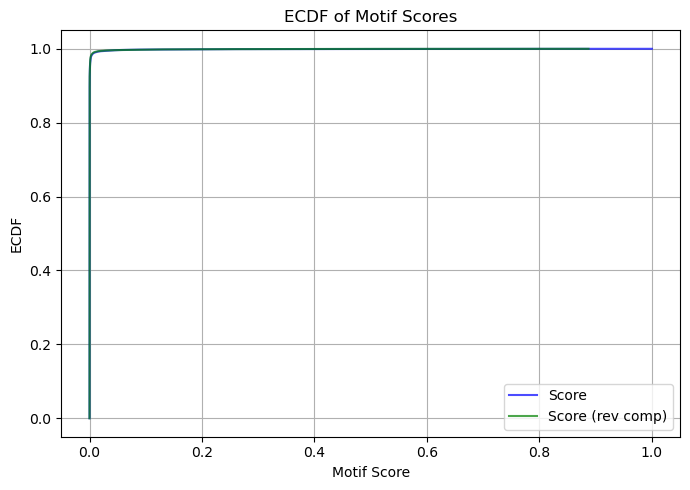

In [198]:
plot_ecdf_compare(count_table_scored)

In [157]:
in_m = BC10_in[BC10_in['methl'] == 'AGTA']

In [200]:
# randomly choose n rows from in_m
bck_sample = in_m.sample(n=10000)

In [201]:
bck_sample = utils.kmer_counting(bck_sample, kmer=12, one_df=True)

In [202]:
bck_scored = score_words_and_reverse(bck_sample, word_col='kmer', psam=psam_m)

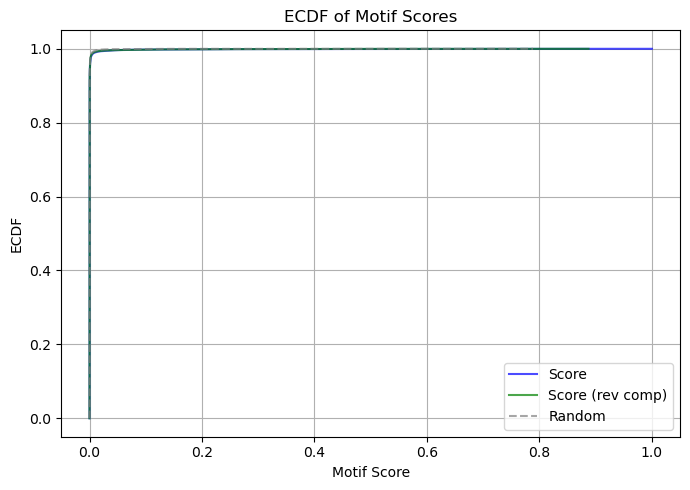

In [206]:
plot_ecdf_compare(count_table_scored, random_scores=bck_scored['score'])

In [207]:
df_expanded = count_table_scored.loc[count_table_scored.index.repeat(count_table_scored['count'].astype(int))].reset_index(drop=True)

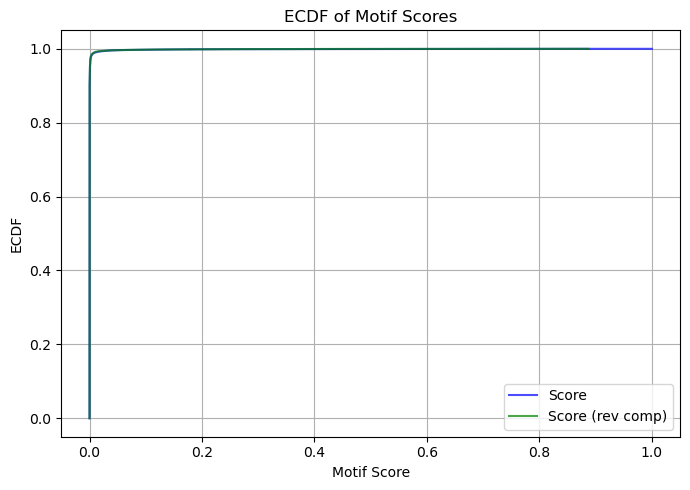

In [212]:
plot_ecdf_compare(df_expanded)

In [213]:
values = np.sort(df_expanded['score'])
ecdf = np.arange(1, len(values) + 1) / len(values)

In [233]:
quantile_95_s = df_expanded['score'].quantile(0.99)
quantile_95_rev = df_expanded['score_rev'].quantile(0.99)
top_1 = df_expanded[(df_expanded['score'] >= quantile_95_s) & (df_expanded['score'] >= quantile_95_rev)]


In [234]:
top_1

,kmer,count,mod,status,score,score_rev
12,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
13,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
14,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
350,GCAACGGGTGCG,1.0,methl,None,0.146838,0.000950
787,CCCGCGGGTGGC,3.0,methl,None,0.272502,0.000250
...,...,...,...,...,...,...
134213,AGCGCAGGTGCC,2.0,methl,None,0.055675,0.000099
134445,ATCACGGGTGGA,1.0,methl,None,0.088499,0.002132
134509,AGGGCTGGTACT,1.0,methl,None,0.027877,0.000035
134575,GCGGCGGGTGAG,1.0,methl,None,0.081666,0.000091


In [219]:
bck_exp = bck_scored.loc[bck_scored.index.repeat(bck_scored['count'].astype(int))].reset_index(drop=True)

In [235]:
a = bck_exp['score'].quantile(0.99)
b = bck_exp['score_rev'].quantile(0.99)
ab5 = bck_exp[(bck_exp['score'] >= a) & (bck_exp['score'] >= b)]

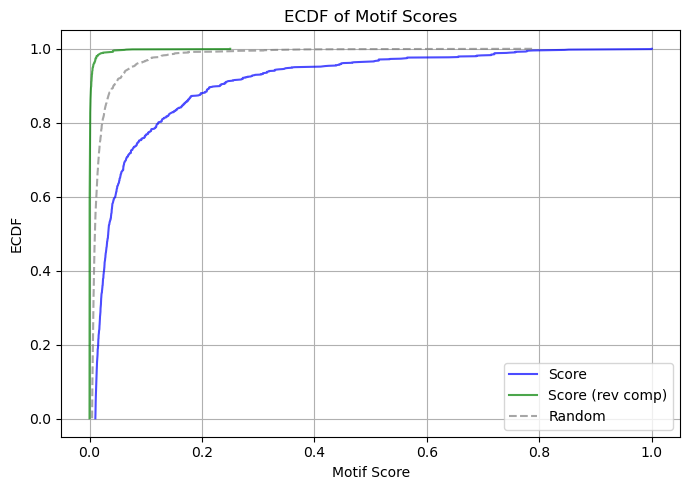

In [236]:
plot_ecdf_compare(top_1,random_scores=ab5['score'])

In [237]:
top_1

,kmer,count,mod,status,score,score_rev
12,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
13,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
14,TTAACCGGTATC,3.0,methl,None,0.049253,0.001962
350,GCAACGGGTGCG,1.0,methl,None,0.146838,0.000950
787,CCCGCGGGTGGC,3.0,methl,None,0.272502,0.000250
...,...,...,...,...,...,...
134213,AGCGCAGGTGCC,2.0,methl,None,0.055675,0.000099
134445,ATCACGGGTGGA,1.0,methl,None,0.088499,0.002132
134509,AGGGCTGGTACT,1.0,methl,None,0.027877,0.000035
134575,GCGGCGGGTGAG,1.0,methl,None,0.081666,0.000091


In [238]:
import collections
import itertools 

def compute_dinucleotide_matrix(df, seq_col):
    """
    Compute a dinucleotide frequency matrix from sequences in a DataFrame column.

    Parameters:
    df : pd.DataFrame
        DataFrame containing sequences
    seq_col : str
        Name of the column containing DNA sequences

    Returns:
    pd.DataFrame
        Dinucleotide frequency matrix with positions as rows and dinucleotides as columns
    """
    dinucs = [''.join(p) for p in itertools.product('ACGT', repeat=2)]
    seqs = df[seq_col].dropna().astype(str)

    # Ensure all sequences are same length
    seq_length = seqs.str.len().mode()[0]
    seqs = seqs[seqs.str.len() == seq_length]
    
    dinuc_counts = [collections.Counter() for _ in range(seq_length - 1)]

    for seq in seqs:
        for i in range(len(seq) - 1):
            dinuc = seq[i:i+2]
            if all(base in 'ACGT' for base in dinuc):
                dinuc_counts[i][dinuc] += 1

    # Convert counters to a DataFrame
    df_matrix = pd.DataFrame([{dn: c.get(dn, 0) for dn in dinucs} for c in dinuc_counts])
    # Normalize to get frequencies
    df_matrix = df_matrix.div(df_matrix.sum(axis=1), axis=0)

    return df_matrix


In [243]:
len(top_1['kmer'][12])

12

In [239]:
compute_dinucleotide_matrix(top_1, seq_col='kmer')

,AA,AC,AG,AT,CA,CC,CG,CT,GA,GC,GG,GT,TA,TC,TG,TT
0,0.019274,0.090437,0.045960,0.051149,0.032617,0.062268,0.036323,0.079318,0.032617,0.098592,0.080801,0.131950,0.022239,0.079318,0.063751,0.073388
1,0.024463,0.017050,0.040771,0.024463,0.128984,0.028169,0.117865,0.055597,0.051149,0.028910,0.084507,0.062268,0.128984,0.042254,0.104522,0.060044
2,0.137880,0.022239,0.161601,0.011861,0.043736,0.000741,0.064492,0.007413,0.137880,0.012602,0.170497,0.026686,0.083024,0.003706,0.108228,0.007413
3,0.010378,0.375834,0.006672,0.009637,0.000000,0.037806,0.000000,0.001483,0.010378,0.426983,0.034099,0.033358,0.000000,0.052632,0.000000,0.000741
4,0.001483,0.004448,0.009637,0.005189,0.213491,0.143069,0.321720,0.214974,0.003706,0.000000,0.005189,0.031875,0.009637,0.005189,0.019274,0.011119
5,0.010378,0.002965,0.209785,0.005189,0.003706,0.003706,0.144552,0.000741,0.016308,0.009637,0.318755,0.011119,0.008154,0.003706,0.247591,0.003706
6,0.000000,0.000000,0.038547,0.000000,0.000000,0.000000,0.020015,0.000000,0.010378,0.029652,0.865827,0.014826,0.000000,0.000000,0.020756,0.000000
7,0.000000,0.000000,0.000000,0.010378,0.000000,0.000000,0.000000,0.029652,0.022239,0.009637,0.016308,0.896961,0.000000,0.000000,0.000000,0.014826
8,0.002965,0.000741,0.018532,0.000000,0.000000,0.000000,0.009637,0.000000,0.001483,0.000000,0.014826,0.000000,0.191253,0.079318,0.614529,0.066716
9,0.026686,0.071164,0.062268,0.035582,0.006672,0.028169,0.033358,0.011861,0.057821,0.114159,0.383988,0.101557,0.007413,0.027428,0.023721,0.008154


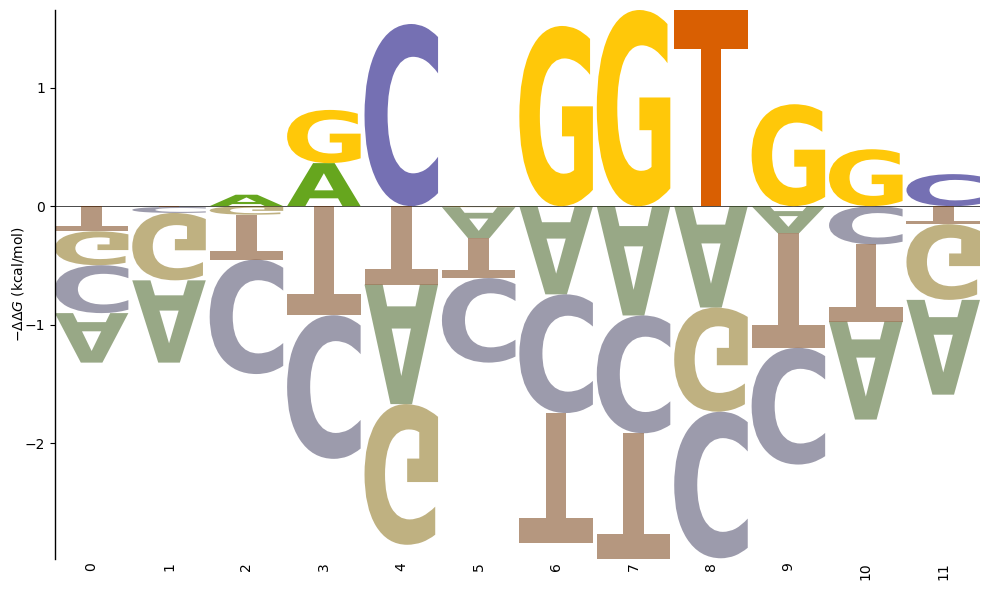

<Axes: ylabel='$-\\Delta \\Delta G$ (kcal/mol)'>

In [244]:
utils.make_logo(dGGm)

In [245]:
compute_dinucleotide_matrix(ab5, seq_col='kmer')

,AA,AC,AG,AT,CA,CC,CG,CT,GA,GC,GG,GT,TA,TC,TG,TT
0,0.026154,0.078462,0.039231,0.081538,0.039231,0.070769,0.046923,0.086154,0.033077,0.082308,0.063846,0.106154,0.046154,0.074615,0.047692,0.077692
1,0.045385,0.020769,0.041538,0.036923,0.121538,0.036923,0.083077,0.064615,0.067692,0.030769,0.065385,0.033846,0.121538,0.038462,0.110769,0.080769
2,0.120769,0.032308,0.155385,0.047692,0.050000,0.010000,0.054615,0.012308,0.110000,0.024615,0.137692,0.028462,0.082308,0.015385,0.100000,0.018462
3,0.019231,0.293077,0.020000,0.030769,0.000769,0.076154,0.000769,0.004615,0.029231,0.359231,0.013846,0.045385,0.003077,0.090769,0.003846,0.009231
4,0.010769,0.005385,0.019231,0.016923,0.212308,0.137692,0.280769,0.188462,0.010769,0.003846,0.017692,0.006154,0.026154,0.012308,0.031538,0.020000
5,0.019231,0.011538,0.210769,0.018462,0.012308,0.006154,0.131538,0.009231,0.025385,0.017692,0.286923,0.019231,0.016923,0.010000,0.190769,0.013846
6,0.000000,0.001538,0.072308,0.000000,0.000000,0.000000,0.045385,0.000000,0.044615,0.051538,0.675385,0.048462,0.000000,0.000000,0.060769,0.000000
7,0.000000,0.000000,0.000000,0.044615,0.000769,0.000000,0.000000,0.052308,0.050000,0.035385,0.065385,0.703077,0.000000,0.000000,0.000000,0.048462
8,0.006923,0.001538,0.038462,0.003846,0.006923,0.000000,0.027692,0.000769,0.009231,0.003077,0.050769,0.002308,0.206923,0.089231,0.467692,0.084615
9,0.016923,0.053077,0.130769,0.029231,0.011538,0.018462,0.052308,0.011538,0.083846,0.150000,0.251538,0.099231,0.007692,0.019231,0.053846,0.010769
